# Imports

In [1]:
#pip freeze > requirements.txt

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from olist.data import Olist

import utils.UVA as UVA
import utils.MVA as MVA
import utils.PCA as PCA

import geopandas as gpd
from geopandas.tools import sjoin
import folium
from folium import plugins

#from imblearn.over_sampling import SMOTENC

In [4]:
from sklearn.feature_selection import VarianceThreshold

In [5]:
#data = Olist().get_data()
data = Olist().get_data()

In [6]:
import warnings
warnings.filterwarnings('ignore')


%matplotlib inline
pd.options.mode.chained_assignment = None  # default='warn'

In [7]:
pd.set_option('display.max_rows', 750)
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', None)

# Exploratory Analysis

### 1 - Run an exploratory analysis with [pandas profiling](https://github.com/pandas-profiling/pandas-profiling)

In [8]:
#! pip install pandas-profiling

In [9]:
# create a new "/reports" folder 
!mkdir -p data/reports

La syntaxe de la commande n'est pas correcte.


In [10]:
list_datas = list(data.keys())
list_datas

['customers',
 'product_category_name_translation',
 'order_items',
 'order_payments',
 'orders',
 'state_codes',
 'products',
 'geolocation',
 'order_reviews',
 'sellers']

In [11]:
#import pandas_profiling
#datasets_to_profile = ['orders', 'products', 'sellers','customers', 'order_reviews','order_items']
datasets_to_profile = list_datas

In [12]:
#for d in datasets_to_profile:
#    print('exporting: '+d)
#    profile = data[d].profile_report(title='Report for '+d)
#    profile.to_file(output_file="data/reports/"+d+'.html');

In [13]:
dict_info = {"dataset": []
        ,"columns": []
        ,"total_rows": []
        ,"total_cols": []
        ,"total_duplicates": []
        ,"total_null": []
        ,"null_cols": []
}

for csv in datasets_to_profile:
    dict_info["dataset"].append(csv) 
    dict_info["columns"].append([', '.join([col for col, null in data[csv].isnull().sum().items() ])])
    dict_info["total_rows"].append(data[csv].shape[0])
    dict_info["total_cols"].append(data[csv].shape[1])
    dict_info["total_duplicates"].append(len(data[csv][data[csv].duplicated()]))
    dict_info["total_null"].append(data[csv].isnull().sum().sum())
    dict_info["null_cols"].append([', '.join([col for col, null in data[csv].isnull().sum().items() if null > 0])])
    
dict_info_df = pd.DataFrame.from_dict(dict_info)
dict_info_df.style.background_gradient(cmap='YlGnBu')

,dataset,columns,total_rows,total_cols,total_duplicates,total_null,null_cols
0,customers,"['customer_id, customer_unique_id, customer_zip_code_prefix, customer_city, customer_state']",99441,5,0,0,['']
1,product_category_name_translation,"['product_category_name, product_category_name_english']",71,2,0,0,['']
2,order_items,"['order_id, order_item_id, product_id, seller_id, shipping_limit_date, price, freight_value']",112650,7,0,0,['']
3,order_payments,"['order_id, payment_sequential, payment_type, payment_installments, payment_value']",103886,5,0,0,['']
4,orders,"['order_id, customer_id, order_status, order_purchase_timestamp, order_approved_at, order_delivered_carrier_date, order_delivered_customer_date, order_estimated_delivery_date']",99441,8,0,4908,"['order_approved_at, order_delivered_carrier_date, order_delivered_customer_date']"
5,state_codes,"['subdivision, region, name_prefix, name, id, idIBGE, wdId, lexLabel, creation, extinction, category, timeZone, utcOffset, utcOffset_DST, postalCode_ranges, km2, borders, centroid_geohash, utm_zones, bounds_geohash, bounds_lat, bounds_long, notes']",33,23,0,129,"['region, name_prefix, idIBGE, extinction, timeZone, utcOffset, utcOffset_DST, postalCode_ranges, km2, borders, centroid_geohash, utm_zones, bounds_geohash, bounds_lat, bounds_long, notes']"
6,products,"['product_id, product_category_name, product_name_lenght, product_description_lenght, product_photos_qty, product_weight_g, product_length_cm, product_height_cm, product_width_cm']",32951,9,0,2448,"['product_category_name, product_name_lenght, product_description_lenght, product_photos_qty, product_weight_g, product_length_cm, product_height_cm, product_width_cm']"
7,geolocation,"['geolocation_zip_code_prefix, geolocation_lat, geolocation_lng, geolocation_city, geolocation_state']",1000163,5,261831,0,['']
8,order_reviews,"['review_id, order_id, review_score, review_comment_title, review_comment_message, review_creation_date, review_answer_timestamp']",99224,7,0,145903,"['review_comment_title, review_comment_message']"
9,sellers,"['seller_id, seller_zip_code_prefix, seller_city, seller_state']",3095,4,0,0,['']


In [14]:
#dict_info_df[['columns']].style.hide_index()

In [15]:
data['geolocation'][data['geolocation'].duplicated() == True]

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
15,1046,-23.546081,-46.644820,sao paulo,SP
44,1046,-23.546081,-46.644820,sao paulo,SP
65,1046,-23.546081,-46.644820,sao paulo,SP
66,1009,-23.546935,-46.636588,sao paulo,SP
67,1046,-23.546081,-46.644820,sao paulo,SP
...,...,...,...,...,...
1000153,99970,-28.343273,-51.873734,ciriaco,RS
1000154,99950,-28.070493,-52.011342,tapejara,RS
1000159,99900,-27.877125,-52.224882,getulio vargas,RS
1000160,99950,-28.071855,-52.014716,tapejara,RS


In [16]:
# check payment types
data['order_payments']['payment_type'].value_counts()

credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: payment_type, dtype: int64

In [17]:
# dropping nulls
#for csv in datasets_to_profile:
#    data[csv].dropna(inplace=True)

In [18]:
data['products']['product_category_name'].isnull().value_counts()

False    32341
True       610
Name: product_category_name, dtype: int64

In [19]:
data['products']['product_category_name'].fillna("unknown", inplace=True)
data['products']['product_category_name'].isnull().value_counts()

False    32951
Name: product_category_name, dtype: int64

In [20]:
# add unknown to matching table
unknown_append = {'product_category_name': 'unknown', 'product_category_name_english':'unknown'}
data['product_category_name_translation'] = data['product_category_name_translation']\
                                            .append(unknown_append, ignore_index=True)

data['product_category_name_translation']

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor
5,esporte_lazer,sports_leisure
6,perfumaria,perfumery
7,utilidades_domesticas,housewares
8,telefonia,telephony
9,relogios_presentes,watches_gifts


In [21]:
# dropping duplicates
for csv in datasets_to_profile:
    data[csv].drop(data[csv][data[csv].duplicated()].index, axis=0, inplace=True)

In [22]:
# recheck :
dict_info = {"dataset": []
        ,"columns": []
        ,"total_rows": []
        ,"total_cols": []
        ,"total_duplicates": []
        ,"total_null": []
        ,"null_cols": []
}

for csv in datasets_to_profile:
    dict_info["dataset"].append(csv) 
    dict_info["columns"].append([', '.join([col for col, null in data[csv].isnull().sum().items() ])])
    dict_info["total_rows"].append(data[csv].shape[0])
    dict_info["total_cols"].append(data[csv].shape[1])
    dict_info["total_duplicates"].append(len(data[csv][data[csv].duplicated()]))
    dict_info["total_null"].append(data[csv].isnull().sum().sum())
    dict_info["null_cols"].append([', '.join([col for col, null in data[csv].isnull().sum().items() if null > 0])])
    
dict_info_df = pd.DataFrame.from_dict(dict_info)
dict_info_df.style.background_gradient(cmap='YlGnBu')

,dataset,columns,total_rows,total_cols,total_duplicates,total_null,null_cols
0,customers,"['customer_id, customer_unique_id, customer_zip_code_prefix, customer_city, customer_state']",99441,5,0,0,['']
1,product_category_name_translation,"['product_category_name, product_category_name_english']",72,2,0,0,['']
2,order_items,"['order_id, order_item_id, product_id, seller_id, shipping_limit_date, price, freight_value']",112650,7,0,0,['']
3,order_payments,"['order_id, payment_sequential, payment_type, payment_installments, payment_value']",103886,5,0,0,['']
4,orders,"['order_id, customer_id, order_status, order_purchase_timestamp, order_approved_at, order_delivered_carrier_date, order_delivered_customer_date, order_estimated_delivery_date']",99441,8,0,4908,"['order_approved_at, order_delivered_carrier_date, order_delivered_customer_date']"
5,state_codes,"['subdivision, region, name_prefix, name, id, idIBGE, wdId, lexLabel, creation, extinction, category, timeZone, utcOffset, utcOffset_DST, postalCode_ranges, km2, borders, centroid_geohash, utm_zones, bounds_geohash, bounds_lat, bounds_long, notes']",33,23,0,129,"['region, name_prefix, idIBGE, extinction, timeZone, utcOffset, utcOffset_DST, postalCode_ranges, km2, borders, centroid_geohash, utm_zones, bounds_geohash, bounds_lat, bounds_long, notes']"
6,products,"['product_id, product_category_name, product_name_lenght, product_description_lenght, product_photos_qty, product_weight_g, product_length_cm, product_height_cm, product_width_cm']",32951,9,0,1838,"['product_name_lenght, product_description_lenght, product_photos_qty, product_weight_g, product_length_cm, product_height_cm, product_width_cm']"
7,geolocation,"['geolocation_zip_code_prefix, geolocation_lat, geolocation_lng, geolocation_city, geolocation_state']",738332,5,0,0,['']
8,order_reviews,"['review_id, order_id, review_score, review_comment_title, review_comment_message, review_creation_date, review_answer_timestamp']",99224,7,0,145903,"['review_comment_title, review_comment_message']"
9,sellers,"['seller_id, seller_zip_code_prefix, seller_city, seller_state']",3095,4,0,0,['']


# Feature Extraction

## - Creating an order matching table

Looking at our schema, it would be best to create a central `matching_table` that will join the most important foreign keys together, for later use

❓Create the `matching_table`, a DataFrame with the following columns (below).  
Use outer joins to make sure you don't lose any information at this stage.

In [23]:
columns_matching_table = [
    "order_id",
    "review_id",
    "customer_id",
    "product_id",
    "seller_id",
]

In [24]:
#### Select only the columns of interest in the various dataframes of interest, before proceeding to any merge
orders = data['orders'][['customer_id', 'order_id']]
reviews = data['order_reviews'][['order_id', 'review_id', 'review_score', 'review_comment_message']]
items = data['order_items'][['order_id', 'product_id','seller_id', 'price']]

#customers = data['customers'][['customer_id', 'customer_unique_id']]
customers = data['customers']
products = data['products']
product_names = data['product_category_name_translation']
payments = data['order_payments']
geo = data['geolocation']

In [25]:
# TODO : add and check new columns
orders = data['orders']
items = data['order_items']
reviews = data['order_reviews']
sellers = data['sellers']



In [26]:
# timestamps orders : data casting
data['orders']["order_purchase_timestamp"] = pd.to_datetime(data['orders']["order_purchase_timestamp"])
data['orders']["order_delivered_carrier_date"] = pd.to_datetime(data['orders']["order_delivered_carrier_date"])
data['orders']["order_delivered_customer_date"] = pd.to_datetime(data['orders']["order_delivered_customer_date"])
data['orders']["order_estimated_delivery_date"] = pd.to_datetime(data['orders']["order_estimated_delivery_date"])

In [27]:
# Inspect the cardinality of each DataFrame using pd.DataFrame.shape and pd.Series.nunique()
print('orders:', orders.shape, orders.customer_id.nunique(), 'unique customer_ids, and', orders.order_id.nunique(), 'unique order_ids')
print('review: ', reviews.shape, reviews.order_id.nunique(), 'unique order_ids and', reviews.review_id.nunique(), 'unique reviews' )
print('items: ', items.shape, items.order_id.nunique(), 'unique order_ids,', items.product_id.nunique(), 
      'unique product_ids, and', items.seller_id.nunique(), 'unique seller_ids')

orders: (99441, 8) 99441 unique customer_ids, and 99441 unique order_ids
review:  (99224, 7) 98673 unique order_ids and 98410 unique reviews
items:  (112650, 7) 98666 unique order_ids, 32951 unique product_ids, and 3095 unique seller_ids


## Orders merge

In [28]:
# Carefully merge DataFrames
matching_table = orders.merge(reviews, on='order_id', how='left').merge(items, on='order_id', how='left')
matching_table

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio correto e em boas condições. Apenas a caixa que veio bem amassada e danificada, o que ficará chato, pois se trata de um presente.",2017-10-11 00:00:00,2017-10-12 03:43:48,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,359d03e676b3c069f62cadba8dd3f6e8,5.0,NaN,O produto foi exatamente o que eu esperava e estava descrito no site e chegou bem antes da data prevista.,2017-12-03 00:00:00,2017-12-05 19:21:58,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,e50934924e227544ba8246aeb3770dd4,5.0,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114087,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,29bb71b2760d0f876dfa178a76bc4734,4.0,NaN,So uma peça que veio rachado mas tudo bem rs,2018-03-01 00:00:00,2018-03-02 17:50:01,1.0,f1d4ce8c6dd66c47bbaa8c6781c2a923,1f9ab4708f3056ede07124aad39a2554,2018-02-12 13:10:37,174.90,20.10
114088,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,371579771219f6db2d830d50805977bb,5.0,NaN,Foi entregue antes do prazo.,2017-09-22 00:00:00,2017-09-22 23:10:57,1.0,b80910977a37536adeddd63663f916ad,d50d79cb34e38265a8649c383dcffd48,2017-09-05 15:04:16,205.99,65.02
114089,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,8ab6855b9fe9b812cd03a480a25058a1,2.0,NaN,Foi entregue somente 1. Quero saber do outro produto.,2018-01-26 00:00:00,2018-01-27 09:16:56,1.0,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-01-12 21:36:21,179.99,40.59
114090,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,8ab6855b9fe9b812cd03a480a25058a1,2.0,NaN,Foi entregue somente 1. Quero saber do outro produto.,2018-01-26

In [29]:
matching_table = orders\
        .merge(customers, on='customer_id', how='outer')\
        .merge(reviews, on="order_id", how="outer")\
        .merge(items, on="order_id", how="outer")\
        .merge(sellers, on='seller_id', how='outer')
matching_table

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio correto e em boas condições. Apenas a caixa que veio bem amassada e danificada, o que ficará chato, pois se trata de um presente.",2017-10-11 00:00:00,2017-10-12 03:43:48,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,9350.0,maua,SP
1,8736140c61ea584cb4250074756d8f3b,ab8844663ae049fda8baf15fc928f47f,delivered,2017-08-10 13:35:55,2017-08-10 13:50:09,2017-08-11 13:52:35,2017-08-16 19:03:36,2017-08-23,02c9e0c05a817d4562ec0e8c90f29dba,8577,itaquaquecetuba,SP,b8238c6515192f8129081e17dc57d169,5.0,NaN,"custo beneficio, simples de usar e rápido",2017-08-17 00:00:00,2017-08-21 12:43:27,1.0,b00a32a0b42fd65efb58a5822009f629,3504c0cb71d7fa48d967e0e4c94d59d9,2017-08-16 13:50:09,75.90,7.79,9350.0,maua,SP
2,a0151737f2f0c6c0a5fd69d45f66ceea,fc2697314ab7fbeda62bb6f1afa4efcd,delivered,2017-07-12 14:11:58,2017-07-12 14:30:18,2017-07-13 12:47:05,2017-07-18 16:24:42,2017-07-25,bdd30e6e39cc70dde8665187b57af402,13820,jaguariuna,SP,fa5bf792d42ed25f80c54d18aeaa83de,4.0,NaN,NaN,2017-07-19 00:00:00,2017-07-24 13:59:59,1.0,725cbfcaff95a4d43742fdf13cf43c75,3504c0cb71d7fa48d967e0e4c94d59d9,2017-07-18 14:30:18,44.99,7.78,9350.0,maua,SP
3,a3bf941183211246f0d42ad757cba127,3718e1873d5dc3e8d96c0ab783278b02,delivered,2017-07-24 22:16:25,2017-07-25 22:25:11,2017-07-26 14:57:42,2017-07-28 19:06:46,2017-08-04,1bcb517dc3cc80868d2fa941174f386c,6298,osasco,SP,5fe3f65882f521f0fbc41e59b9fbff24,4.0,NaN,NaN,2017-07-29 00:00:00,2017-08-01 20:06:40,1.0,725cbfcaff95a4d43742fdf13cf43c75,3504c0cb71d7fa48d967e0e4c94d59d9,2017-07-31 22:25:11,44.99,7.78,9350.0,maua,SP
4,1462290799412b71be32dd880eaf4e1b,220e4b027f0294fd79d2869ef67e7db6,delivered,2017-08-19 14:06:58,2017-08-22 04:10:55,2017-08-23 13:54:29,2017-08-29 19:35:06,2017-09-15,123ae28184c9e80638e71d40e37adc27,94130,gravatai,RS,36f6f70dc5e67e8e43b109cae0e92d40,4.0,NaN,É garantido e de confiança .,2017-08-30 00:00:00,2017-08-31 02:21:39,1.0,d7faab3fa0091d1220a8ada9cae1bab3,3504c0cb71d7fa48d967e0e4c94d59d9,2017-08-28 04:10:55,29.90,14.10,9350.0,maua,SP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114087,1ab38815794efa43d269d62b98dae815,a0b67404d84a70ef420a7f99ad6b190a,delivered,2018-07-01 10:23:10,2018-07-05 16:17:52,2018-07-04 14:34:00,2018-07-09 15:06:57,2018-07-20,2077f7ec37df79c62cc24b7b8f30e8c9,8528,ferraz de vasconcelos,SP,7f9849fcbfdf9fa3070c05b5501bf066,5.0,NaN,NaN,2018-07-10 00:00:00,2018-07-10 18:32:29,1.0,31ec3a565e06de4bdf9d2a511b822b4d,babcc0ab201e4c60188427cae51a5b8b,2018-07-10 08:32:33,79.00,14.13,13660.0,porto ferreira,SP
114088,b159d0ce7cd881052da94fa165617b05,e0c3bc5ce0836b975d6b2a8ce7bb0e3e,canceled,2017-03-11 19:51:36,2017-03-11 19:51:36,NaT,NaT,2017-03-30,78a159045124eb7601951b917a42034f,89111,gaspar,SC,c950324a42c5796d06f569f77d8b2e88,1.0,NaN,NaN,2017-04-01 00:00:00,2017-04-01 10:24:03,1.0,241a1ffc9cf969b27de6e72301020268,8501d82f68d23148b6d78bb7c4a42037,2017-03-16 19:51:36,19.70,10.96,89031.0,blumenau,SC
114089,735dce2d574afe8eb87e80a3d6229c48,d531d01affc2c55769f6b9ed410d8d3c,delivered,2018-07-24 09:46:27,2018-07-24 11:24:27,2018-07-24 15:14:00,2018-08-02 22:47:35,2018-08-16,8cf3c6e1d2c8afaab2eda3fa01d4e3d2,60455,fortalez

In [30]:
# test get matching table
matching_table_import = Olist().get_matching_table()
matching_table_import

,customer_id,order_id,customer_unique_id,review_id,product_id,seller_id
0,9ef432eb6251297304e76186b10a928d,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,a54f0611adc9ed256b57ede6b6eb5114,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9
1,b0830fb4747a6c6d20dea0b8c802d7ef,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,8d5266042046a06655c8db133d120ba5,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962
2,41ce2a54c0b03bf3443c3d931a367089,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,e73b67b67587f7644d5bd1a52deb1b01,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2
3,f88197465ea7920adcdbec7375364d82,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,359d03e676b3c069f62cadba8dd3f6e8,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106
4,8ab97904e6daea8866dbdbc4fb7aad2c,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,e50934924e227544ba8246aeb3770dd4,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8
...,...,...,...,...,...,...
114087,1fca14ff2861355f6e5f14306ff977a7,63943bddc261676b46f01ca7ac2f7bd8,da62f9e57a76d978d02ab5362c509660,29bb71b2760d0f876dfa178a76bc4734,f1d4ce8c6dd66c47bbaa8c6781c2a923,1f9ab4708f3056ede07124aad39a2554
114088,1aa71eb042121263aafbe80c1b562c9c,83c1379a015df1e13d02aae0204711ab,737520a9aad80b3fbbdad19b66b37b30,371579771219f6db2d830d50805977bb,b80910977a37536adeddd63663f916ad,d50d79cb34e38265a8649c383dcffd48
114089,b331b74b18dc79bcdf6532d51e1637c1,11c177c8e97725db2631073c19f07b62,5097a5312c8b157bb7be58ae360ef43c,8ab6855b9fe9b812cd03a480a25058a1,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48
114090,b331b74b18dc79bcdf6532d51e1637c1,11c177c8e97725db2631073c19f07b62,5097a5312c8b157bb7be58ae360ef43c,8ab6855b9fe9b812cd03a480a25058a1,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48


In [31]:
# Inspect the cardinality and `nunique` of the final DataFrame. It should match (114100, 5)
print(matching_table.shape)
print('unique values: ')
print(matching_table.nunique())

(114092, 27)
unique values: 
order_id                         99441
customer_id                      99441
order_status                         8
order_purchase_timestamp         98875
order_approved_at                90733
order_delivered_carrier_date     81018
order_delivered_customer_date    95664
order_estimated_delivery_date      459
customer_unique_id               96096
customer_zip_code_prefix         14994
customer_city                     4119
customer_state                      27
review_id                        98410
review_score                         5
review_comment_title              4527
review_comment_message           36159
review_creation_date               636
review_answer_timestamp          98248
order_item_id                       21
product_id                       32951
seller_id                         3095
shipping_limit_date              93318
price                             5968
freight_value                     6999
seller_zip_code_prefix            2

In [32]:
matching_table['order_id'].duplicated().sum()

14651

In [33]:
matching_table.loc[matching_table['order_id'].duplicated()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,seller_zip_code_prefix,seller_city,seller_state
57,c6094f6ab0c25eda761622ab09aa423d,69ee62ecc8d2937fca0e1a3d4de5a2ce,delivered,2018-07-25 10:16:15,2018-07-25 10:30:20,2018-07-26 14:31:00,2018-07-30 17:29:34,2018-08-22,9b82602fc3e9a153752f16553752d58d,21930,rio de janeiro,RJ,d266ab294a1fa257804bea470618c8c5,5.0,Perfeito!,"Adorei, os produtos chegaram bem antes do prazo, menos de uma semana, tudo bem embalado, o entregador chamou alto o q possibilita de ouvir e atender, mto bom, recomendo muito.",2018-07-31 00:00:00,2018-08-01 01:48:47,2.0,0f91b6a95a57a43203a9b17de98960d9,289cdb325fb7e7f891c38608bf9e0962,2018-07-27 10:30:20,119.30,15.93,31570.0,belo horizonte,SP
75,c94edffab2f10ec24645c62b40881e88,83e4193ef8adca21142f06ba078bf556,delivered,2018-08-25 14:05:07,2018-08-26 13:55:19,2018-08-27 14:36:00,2018-08-29 11:44:40,2018-09-11,3ff9132b9f4a7e46118e5347c765f77b,23035,rio de janeiro,RJ,4c9edf9090763f01b46103e2e218c926,3.0,NaN,NaN,2018-08-30 00:00:00,2018-08-30 16:53:52,2.0,fbc1488c1a1e72ba175f53ab29a248e8,289cdb325fb7e7f891c38608bf9e0962,2018-08-28 13:55:19,116.90,15.92,31570.0,belo horizonte,SP
77,d543201a9b42a1402ff97e65b439a48b,971bf8f42a9f8cb3ead257854905b454,delivered,2018-08-21 10:00:25,2018-08-21 10:50:54,2018-08-22 15:21:00,2018-08-28 18:58:22,2018-09-10,958ac7760e5484df1496ba5833ab6117,89117,gaspar,SC,8892abc02a527ef7535564ecfc0d0133,5.0,super recomendo,"entrega no prazo, amei",2018-08-29 00:00:00,2018-09-11 12:15:59,2.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-08-23 10:50:54,116.90,22.75,31570.0,belo horizonte,SP
80,c0fc5c6702f93ec8646c5404b4147864,6eed4ef57344486d5a44b9b8e23913c2,delivered,2018-08-20 12:14:50,2018-08-20 15:36:05,2018-08-21 14:56:00,2018-08-23 14:46:50,2018-09-04,e67ac9785a0dbbb134040135a75cdb71,22450,rio de janeiro,RJ,3353bb5244d0ae8b7a7f83c3acedc009,5.0,NaN,NaN,2018-08-24 00:00:00,2018-08-24 19:02:59,2.0,0f91b6a95a57a43203a9b17de98960d9,289cdb325fb7e7f891c38608bf9e0962,2018-08-22 15:35:21,116.90,15.92,31570.0,belo horizonte,SP
83,8ecc75b89cac1a60578b65339ad6a169,ab5e250b91db7cff17070cdf5cad37ee,delivered,2018-06-14 14:54:24,2018-06-14 15:20:30,2018-06-15 14:29:00,2018-06-20 11:35:31,2018-07-04,76355fb3e7cfd10805e28e4bfbddda37,38810,rio paranaiba,MG,2f856eb122666743526589f95a658f40,5.0,NaN,NaN,2018-06-21 00:00:00,2018-06-21 15:39:30,2.0,8312d7de87652a517f739c42bb4fd3f0,289cdb325fb7e7f891c38608bf9e0962,2018-06-18 15:20:30,29.90,13.55,31570.0,belo horizonte,SP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114064,c894fad29c885c81201d9bdd80cd68c5,42db86d932ba029e4e0290778ebfc59d,invoiced,2017-12-18 10:39:37,2017-12-19 09:51:49,NaT,NaT,2018-01-05,803c530613f5c4ee03502be0d6894de0,12236,sao jose dos campos,SP,a0cce310b010a5ba8531952af8d2836c,1.0,NaN,Não recebi o produto até o momento. Estou no aguardo de um retorno,2018-01-09 00:00:00,2018-01-09 03:29:32,5.0,0c40401eba358c9ef2ff2df80b6eab52,3bfad056cf05c00dabe2f895925d83b1,2017-12-26 09:51:49,41.33,9.34,6033.0,osasco,SP
114068,b6b9f5144b004ad3db40567cdce34811,8fdfa85118487910ecb24477b00c6ae3,delivered,2018-04-30 10:10:48,2018-04-30 10:31:13,2018-05-07 14:04:00,2018-05-14 16:37:46,2018-05-17,a38640e92b9b5084cad12f3f3b200a83,35057,governador valadares,MG,384e5d48af46db4c863eb5d756566368,5.0,NaN,😃 ótimo 👍,2018-05-15 00:00:00,2018-05-15 22:17:19,2.0,6292e8c74db1d4defdbd8244c1101bb6,a3fa18b3f688ec0fca3eb8bfcbd2d5b3,2018-05-07 10:31:02,23.90,18.23,4557.0,são paulo,SP
114075,d3a84031db6c5de813d5a3a3489712ca,a5bda6def3f77258ca2027b7d4a384e9,delivered,20

In [34]:
matching_table.loc[matching_table['order_id'] == 'acce194856392f074dbf9dada14d8d82']

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,seller_zip_code_prefix,seller_city,seller_state
10640,acce194856392f074dbf9dada14d8d82,7e20bf5ca92da68200643bda76c504c6,delivered,2018-06-04 00:00:13,2018-06-05 00:35:10,2018-06-05 13:24:00,2018-06-16 15:20:55,2018-07-18,576ea0cab426cd8a00fad9a9c90a4494,41213,salvador,BA,2d4303fd561eb4ab51c87faa6598dc10,1.0,NÃO RECOMENDO!!!!,"Até o momento não recebi o produto Protetor De Colchão Para Berço - Algodão Impermeável, já fiz a reclamação desde o dia 18/06 e ainda não obtive retorno. Irei cancelar o pedido e estornar a compra hj",2018-06-17 00:00:00,2018-06-20 11:38:22,1.0,d70f38e7f79c630f8ea00c993897042c,977f9f63dd360c2a32ece2f93ad6d306,2018-06-13 00:35:10,90.9,48.64,14910.0,tabatinga,SP
10665,acce194856392f074dbf9dada14d8d82,7e20bf5ca92da68200643bda76c504c6,delivered,2018-06-04 00:00:13,2018-06-05 00:35:10,2018-06-05 13:24:00,2018-06-16 15:20:55,2018-07-18,576ea0cab426cd8a00fad9a9c90a4494,41213,salvador,BA,2d4303fd561eb4ab51c87faa6598dc10,1.0,NÃO RECOMENDO!!!!,"Até o momento não recebi o produto Protetor De Colchão Para Berço - Algodão Impermeável, já fiz a reclamação desde o dia 18/06 e ainda não obtive retorno. Irei cancelar o pedido e estornar a compra hj",2018-06-17 00:00:00,2018-06-20 11:38:22,2.0,9451e630d725c4bb7a5a206b48b99486,d673a59aac7a70d8b01e6902bf090a11,2018-06-13 00:35:10,39.5,48.64,14940.0,ibitinga,SP


In [35]:
products[products.product_id.isin(['977f9f63dd360c2a32ece2f93ad6d306', '977f9f63dd360c2a32ece2f93ad6d306'])]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm


In [36]:
# check n# orders per customer

In [37]:
#orders = data['orders'][['customer_id', 'order_id']]
#customers = data['customers'][['customer_id', 'customer_unique_id']]

In [38]:
match_orders = orders.merge(customers, on='customer_id', how='left')

In [39]:
match_orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP
...,...,...,...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,6359f309b166b0196dbf7ad2ac62bb5a,12209,sao jose dos campos,SP
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,da62f9e57a76d978d02ab5362c509660,11722,praia grande,SP
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,737520a9aad80b3fbbdad19b66b37b30,45920,nova vicosa,BA
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ


In [40]:
orders_count = match_orders \
                .groupby('customer_unique_id')['order_id'] \
                .nunique().reset_index(name='orders_count')

In [41]:
orders_count['count_category'] = np.where(orders_count['orders_count'] == 1, '1', '2+')

In [42]:
orders_count.sort_values(by='orders_count', ascending=False)

,customer_unique_id,orders_count,count_category
52973,8d50f5eadf50201ccdcedfb9e2ac8455,17,2+
23472,3e43e6105506432c953e165fb2acf44c,9,2+
37797,6469f99c1f9dfae7733b25662e7f1782,7,2+
76082,ca77025e7201e3b30c44b472ff346268,7,2+
10354,1b6c7548a2a1f9037c1fd3ddfed95f33,7,2+
...,...,...,...
32508,5657dfebff5868c4dc7e8355fea865c4,1,1
32507,5657596addb4d7b07b32cd330614bdf8,1,1
32506,5656eb169546146caeab56c3ffc3d268,1,1
32505,5656a8fabc8629ff96b2bc14f8c09a27,1,1


In [43]:
orders_info = pd.concat([orders_count['orders_count'].value_counts(normalize=True),
                        orders_count['orders_count'].value_counts()], 
                        axis=1,
                        keys=('percent','count customers'))
orders_info.index.name = 'orders per customer'
orders_info

,percent,count customers
orders per customer,,
1,0.968812,93099
2,0.028565,2745
3,0.002112,203
4,0.000312,30
5,0.000083,8
6,0.000062,6
7,0.000031,3
9,0.000010,1
17,0.000010,1


In [44]:
orders_info_cum = pd.concat([orders_count['count_category'].value_counts(normalize=True),
                        orders_count['count_category'].value_counts()], 
                        axis=1,
                        keys=('perc','count'))
orders_info_cum.index.name = 'orders per customer'
orders_info_cum

,perc,count
orders per customer,,
1,0.968812,93099
2+,0.031188,2997


=> ~3.12 % of the total of customers (2997 total) has made more than 1 order.

In [45]:
## selecting / merging data for clustering


In [46]:
match_orders = match_orders.merge(orders_count, on='customer_unique_id', how='left')

In [47]:
match_orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,orders_count,count_category
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2,2+
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1,1
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1,1
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1,1
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,6359f309b166b0196dbf7ad2ac62bb5a,12209,sao jose dos campos,SP,1,1
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,da62f9e57a76d978d02ab5362c509660,11722,praia grande,SP,1,1
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,737520a9aad80b3fbbdad19b66b37b30,45920,nova vicosa,BA,1,1
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ,1,1


In [48]:
## picking orders from customers_unique_id having made more than 2 orders 
match_orders_2p = match_orders[['customer_id','order_id', 'customer_unique_id']].loc[match_orders['orders_count'] > 1]
match_orders_2p

,customer_id,order_id,customer_unique_id
0,9ef432eb6251297304e76186b10a928d,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff
15,3b6828a50ffe546942b7a473d70ac0fc,dcb36b511fcac050b97cd5c05de84dc3,ccafc1c3f270410521c3c6f3b249870f
16,738b086814c6fcc74b8cc583f8516ee3,403b97836b0c04a622354cf531062e5f,6e26bbeaa107ec34112c64e1ee31c0f5
44,caded193e8e47b8362864762a83db3c5,ee64d42b8cf066f35eac1cf57de1aa85,08fb46d35bb3ab4037202c23592d1259
46,569cf68214806a39acc0f39344aea67f,d17dc4a904426827ca80f2ccb3a6be56,c2551ea089b7ebbc67a2ea8757152514
...,...,...,...
99307,14945bc802d49b0f9f68f2ea8fd060c4,58edf3f5f282ab91e0f6a6f2b85af02a,62b8761192c86f4ead06f4a433096a2b
99344,e6f5f771cdbc5d09c994f16c9af6523d,bfecb4ee6ab98bff69307aab578db48a,dca9a13536adcef18c6c5859487347b1
99347,2f0524a7b1b3845a1a57fcf3910c4333,a89abace0dcc01eeb267a9660b5ac126,d05c44a138277ad325d915c6b7ccbcdf
99419,ce5efd1b1d8a2fa290a871edd5c26cd6,1b4a0e6b19d0034b531655b41ea89623,39fff7cb5873a7116b02234bd1e6c6dc


In [49]:
match_orders_2p

,customer_id,order_id,customer_unique_id
0,9ef432eb6251297304e76186b10a928d,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff
15,3b6828a50ffe546942b7a473d70ac0fc,dcb36b511fcac050b97cd5c05de84dc3,ccafc1c3f270410521c3c6f3b249870f
16,738b086814c6fcc74b8cc583f8516ee3,403b97836b0c04a622354cf531062e5f,6e26bbeaa107ec34112c64e1ee31c0f5
44,caded193e8e47b8362864762a83db3c5,ee64d42b8cf066f35eac1cf57de1aa85,08fb46d35bb3ab4037202c23592d1259
46,569cf68214806a39acc0f39344aea67f,d17dc4a904426827ca80f2ccb3a6be56,c2551ea089b7ebbc67a2ea8757152514
...,...,...,...
99307,14945bc802d49b0f9f68f2ea8fd060c4,58edf3f5f282ab91e0f6a6f2b85af02a,62b8761192c86f4ead06f4a433096a2b
99344,e6f5f771cdbc5d09c994f16c9af6523d,bfecb4ee6ab98bff69307aab578db48a,dca9a13536adcef18c6c5859487347b1
99347,2f0524a7b1b3845a1a57fcf3910c4333,a89abace0dcc01eeb267a9660b5ac126,d05c44a138277ad325d915c6b7ccbcdf
99419,ce5efd1b1d8a2fa290a871edd5c26cd6,1b4a0e6b19d0034b531655b41ea89623,39fff7cb5873a7116b02234bd1e6c6dc


In [50]:
##  adding orders categories and reviews info

In [51]:
reviews

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela Internet seguro e prático Parabéns a todos feliz Páscoa,2018-03-01 00:00:00,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super recomendo essa loja!",2018-03-22 00:00:00,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13


In [52]:
match_orders_2p

,customer_id,order_id,customer_unique_id
0,9ef432eb6251297304e76186b10a928d,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff
15,3b6828a50ffe546942b7a473d70ac0fc,dcb36b511fcac050b97cd5c05de84dc3,ccafc1c3f270410521c3c6f3b249870f
16,738b086814c6fcc74b8cc583f8516ee3,403b97836b0c04a622354cf531062e5f,6e26bbeaa107ec34112c64e1ee31c0f5
44,caded193e8e47b8362864762a83db3c5,ee64d42b8cf066f35eac1cf57de1aa85,08fb46d35bb3ab4037202c23592d1259
46,569cf68214806a39acc0f39344aea67f,d17dc4a904426827ca80f2ccb3a6be56,c2551ea089b7ebbc67a2ea8757152514
...,...,...,...
99307,14945bc802d49b0f9f68f2ea8fd060c4,58edf3f5f282ab91e0f6a6f2b85af02a,62b8761192c86f4ead06f4a433096a2b
99344,e6f5f771cdbc5d09c994f16c9af6523d,bfecb4ee6ab98bff69307aab578db48a,dca9a13536adcef18c6c5859487347b1
99347,2f0524a7b1b3845a1a57fcf3910c4333,a89abace0dcc01eeb267a9660b5ac126,d05c44a138277ad325d915c6b7ccbcdf
99419,ce5efd1b1d8a2fa290a871edd5c26cd6,1b4a0e6b19d0034b531655b41ea89623,39fff7cb5873a7116b02234bd1e6c6dc


In [53]:
products = products.merge(product_names, on='product_category_name', how='left')
products = products.reindex(['product_id', 'product_category_name',  'product_category_name_english', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'], axis=1)
products

,product_id,product_category_name,product_category_name_english,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,perfumery,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,art,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,sports_leisure,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,baby,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,housewares,37.0,402.0,4.0,625.0,20.0,17.0,13.0
...,...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,furniture_decor,45.0,67.0,2.0,12300.0,40.0,40.0,40.0
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,construction_tools_lights,41.0,971.0,1.0,1700.0,16.0,19.0,16.0
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,bed_bath_table,50.0,799.0,1.0,1400.0,27.0,7.0,27.0
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,computers_accessories,60.0,156.0,2.0,700.0,31.0,13.0,20.0


In [54]:
m_df = match_orders_2p \
    .merge(items[['order_id', 'product_id', 'price']], on='order_id', how='left') \
    .merge(products[['product_id', 'product_category_name_english']], on='product_id', how='left') \
    .merge(reviews, on='order_id', how='left')

In [55]:
m_df

,customer_id,order_id,customer_unique_id,product_id,price,product_category_name_english,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,9ef432eb6251297304e76186b10a928d,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,87285b34884572647811a353c7ac498a,29.99,housewares,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio correto e em boas condições. Apenas a caixa que veio bem amassada e danificada, o que ficará chato, pois se trata de um presente.",2017-10-11 00:00:00,2017-10-12 03:43:48
1,3b6828a50ffe546942b7a473d70ac0fc,dcb36b511fcac050b97cd5c05de84dc3,ccafc1c3f270410521c3c6f3b249870f,009c09f439988bc06a93d6b8186dce73,132.40,perfumery,5a8608437f4b52bec5cd143f37258b5e,5.0,Nota dez,Obrigado pela atenção. Lojas lannister perfeito em tudo.,2018-07-03 00:00:00,2018-07-03 15:10:07
2,738b086814c6fcc74b8cc583f8516ee3,403b97836b0c04a622354cf531062e5f,6e26bbeaa107ec34112c64e1ee31c0f5,638bbb2a5e4f360b71f332ddfebfd672,1299.00,construction_tools_construction,NaN,NaN,NaN,NaN,NaN,NaN
3,caded193e8e47b8362864762a83db3c5,ee64d42b8cf066f35eac1cf57de1aa85,08fb46d35bb3ab4037202c23592d1259,c50ca07e9e4db9ea5011f06802c0aea0,14.49,health_beauty,5853e27c64b89e222c5e4edf78bec3d4,1.0,NaN,NaN,2018-07-01 00:00:00,2018-07-11 20:41:18
4,569cf68214806a39acc0f39344aea67f,d17dc4a904426827ca80f2ccb3a6be56,c2551ea089b7ebbc67a2ea8757152514,ba4bfbf74dbe7ab37e263b9326da0523,36.90,sports_leisure,bcab37e37778893d858b3d159849a56d,4.0,NaN,NaN,2017-05-26 00:00:00,2017-06-01 19:10:49
...,...,...,...,...,...,...,...,...,...,...,...,...
8240,14945bc802d49b0f9f68f2ea8fd060c4,58edf3f5f282ab91e0f6a6f2b85af02a,62b8761192c86f4ead06f4a433096a2b,f5e585e188891ed071253bacfad60820,194.80,computers_accessories,d3006c9fd3bef31b68bd680fe4098202,5.0,TAvaliação da entrega Car,Adquiri 4 cartuchos 41 Canon e recebi somente 2 até o momento.,2018-05-15 00:00:00,2018-05-16 04:42:04
8241,e6f5f771cdbc5d09c994f16c9af6523d,bfecb4ee6ab98bff69307aab578db48a,dca9a13536adcef18c6c5859487347b1,d220fdef3dfe133c5a725ee59ce99595,349.90,auto,dd378bada585d0bd633bf39fc9574548,5.0,NaN,NaN,2018-03-28 00:00:00,2018-03-29 22:27:19
8242,2f0524a7b1b3845a1a57fcf3910c4333,a89abace0dcc01eeb267a9660b5ac126,d05c44a138277ad325d915c6b7ccbcdf,NaN,NaN,NaN,047fd109ced39e02296f6aeb74f6a6f1,4.0,NaN,NaN,2018-07-31 00:00:00,2018-08-02 15:11:49
8243,ce5efd1b1d8a2fa290a871edd5c26cd6,1b4a0e6b19d0034b531655b41ea89623,39fff7cb5873a7116b02234bd1e6c6dc,9e10ae46a3021a02f1692448ef9fa1db,37.90,health_beauty,47697b20bcd3995f870e284fad248ac8,4.0,NaN,NaN,2017-10-07 00:00:00,2017-10-09 22:28:51


In [56]:
# more rows => more items/products total than orders total (i.e. orders with multiple items)
# check out orders with multiple items to be sure it will be usable / absence of duplicates (in price for ex)

In [57]:
product_count = m_df \
                .groupby('order_id')['product_id'] \
                .nunique().reset_index(name='prod_count')
product_count.sort_values(by='prod_count', ascending=False)

,order_id,prod_count
5686,e43f88863d1cc9cff18d753d439d42e8,6
2248,5a3b1c29a49756e75f1ef513383c0c12,6
324,0c57cbfd927d9e62af8beee6d48920b7,5
5075,cc2999bc678cab0949b90c4759d7a284,4
3116,7e3fefb35b0b1d765a343618ca5d454c,4
...,...,...
4579,b90cc9e10252911c2092a1e49794aa13,0
5363,d69fcef5a5fe3a3db60ea65c6ee499cc,0
3038,7a9d4c7f9b068337875b95465330f2fc,0
6148,f81e71dd7c044a9ee7c1d6e37d68d64f,0


In [58]:
product_info = pd.concat([product_count['prod_count'].value_counts(normalize=True),
                        product_count['prod_count'].value_counts()], 
                        axis=1,
                        keys=('percent','count orders'))
product_info.index.name = 'products per order'
product_info

,percent,count orders
products per order,,
1,0.925891,5872
2,0.047304,300
0,0.016872,107
3,0.008199,52
4,0.001261,8
6,0.000315,2
5,0.000158,1


In [59]:
# checking order 5a3b1c29a49756e75f1ef513383c0c12

#m_df.loc[m_df['order_id'] == '5a3b1c29a49756e75f1ef513383c0c12']

# handles duplicates from matching_table (reviews...)
m_df[['product_id', 'price', 'product_category_name_english']]\
.loc[m_df['order_id'] == '5a3b1c29a49756e75f1ef513383c0c12']\
.drop_duplicates()

,product_id,price,product_category_name_english
1415,99444c1e11fc38755dae86f5c67d3d1a,49.99,bed_bath_table
1417,17d8b8e9c21ec0fc5b33724e32fe422e,58.90,bed_bath_table
1419,399f54c06661d06ca45c6e24ed238e0e,61.90,bed_bath_table
1421,6a0713a63e990052795623e76cc2995e,72.90,bed_bath_table
1427,d25bbb182b51d1594fe3b54a27ae143e,69.90,bed_bath_table
1429,e95fb3a80ca294f39de925b6428f3a32,78.90,bed_bath_table


In [60]:
# check products
check_prod = m_df.loc[m_df['order_id'] == '5a3b1c29a49756e75f1ef513383c0c12']['product_id']
products.loc[products['product_id'].isin(check_prod)]

,product_id,product_category_name,product_category_name_english,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
5347,d25bbb182b51d1594fe3b54a27ae143e,cama_mesa_banho,bed_bath_table,34.0,308.0,1.0,1900.0,58.0,15.0,46.0
14912,6a0713a63e990052795623e76cc2995e,cama_mesa_banho,bed_bath_table,31.0,151.0,1.0,900.0,40.0,4.0,30.0
20180,17d8b8e9c21ec0fc5b33724e32fe422e,cama_mesa_banho,bed_bath_table,26.0,212.0,2.0,1000.0,30.0,4.0,40.0
25905,e95fb3a80ca294f39de925b6428f3a32,cama_mesa_banho,bed_bath_table,29.0,263.0,1.0,1300.0,33.0,9.0,38.0
29768,99444c1e11fc38755dae86f5c67d3d1a,cama_mesa_banho,bed_bath_table,40.0,162.0,1.0,900.0,33.0,9.0,38.0
30087,399f54c06661d06ca45c6e24ed238e0e,cama_mesa_banho,bed_bath_table,34.0,216.0,2.0,1100.0,33.0,9.0,38.0


In [61]:
items.loc[items['order_id'] == '5a3b1c29a49756e75f1ef513383c0c12']

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
39679,5a3b1c29a49756e75f1ef513383c0c12,1,99444c1e11fc38755dae86f5c67d3d1a,d2374cbcbb3ca4ab1086534108cc3ab7,2017-10-24 13:06:21,49.99,7.10
39680,5a3b1c29a49756e75f1ef513383c0c12,2,17d8b8e9c21ec0fc5b33724e32fe422e,d2374cbcbb3ca4ab1086534108cc3ab7,2017-10-24 13:06:21,58.90,2.66
39681,5a3b1c29a49756e75f1ef513383c0c12,3,399f54c06661d06ca45c6e24ed238e0e,d2374cbcbb3ca4ab1086534108cc3ab7,2017-10-24 13:06:21,61.90,11.98
39682,5a3b1c29a49756e75f1ef513383c0c12,4,6a0713a63e990052795623e76cc2995e,d2374cbcbb3ca4ab1086534108cc3ab7,2017-10-24 13:06:21,72.90,2.66
39683,5a3b1c29a49756e75f1ef513383c0c12,5,99444c1e11fc38755dae86f5c67d3d1a,d2374cbcbb3ca4ab1086534108cc3ab7,2017-10-24 13:06:21,49.99,7.10
39684,5a3b1c29a49756e75f1ef513383c0c12,6,399f54c06661d06ca45c6e24ed238e0e,d2374cbcbb3ca4ab1086534108cc3ab7,2017-10-24 13:06:21,61.90,11.98
39685,5a3b1c29a49756e75f1ef513383c0c12,7,d25bbb182b51d1594fe3b54a27ae143e,cfb1a033743668a192316f3c6d1d2671,2017-10-24 13:06:21,69.90,33.72
39686,5a3b1c29a49756e75f1ef513383c0c12,8,e95fb3a80ca294f39de925b6428f3a32,d2374cbcbb3ca4ab1086534108cc3ab7,2017-10-24 13:06:21,78.90,7.98
39687,5a3b1c29a49756e75f1ef513383c0c12,9,e95fb3a80ca294f39de925b6428f3a32,d2374cbcbb3ca4ab1086534108cc3ab7,2017-10-24 13:06:21,78.90,7.98
39688,5a3b1c29a49756e75f1ef513383c0c12,10,d25bbb182b51d1594fe3b54a27ae143e,cfb1a033743668a192316f3c6d1d2671,2017-10-24 13:06:21,69.90,33.72


In [62]:
# checking order e43f88863d1cc9cff18d753d439d42e8
m_df.loc[m_df['order_id'] == 'e43f88863d1cc9cff18d753d439d42e8']

,customer_id,order_id,customer_unique_id,product_id,price,product_category_name_english,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
4291,7171389ea6661b64e8c33ee5ad962922,e43f88863d1cc9cff18d753d439d42e8,72061fff095d8325b311ea24e2f4a2b5,9036be77e0a74cca6eeef0740649b97b,69.99,toys,ced64d7d56565e0385d0953d0dc1e4c7,5.0,NaN,NaN,2018-01-05 00:00:00,2018-01-05 11:46:52
4292,7171389ea6661b64e8c33ee5ad962922,e43f88863d1cc9cff18d753d439d42e8,72061fff095d8325b311ea24e2f4a2b5,238314b88e4b8ffa496db6b1a201d897,69.99,toys,ced64d7d56565e0385d0953d0dc1e4c7,5.0,NaN,NaN,2018-01-05 00:00:00,2018-01-05 11:46:52
4293,7171389ea6661b64e8c33ee5ad962922,e43f88863d1cc9cff18d753d439d42e8,72061fff095d8325b311ea24e2f4a2b5,28447390cfd2a411fcb8c008b6163da2,69.99,toys,ced64d7d56565e0385d0953d0dc1e4c7,5.0,NaN,NaN,2018-01-05 00:00:00,2018-01-05 11:46:52
4294,7171389ea6661b64e8c33ee5ad962922,e43f88863d1cc9cff18d753d439d42e8,72061fff095d8325b311ea24e2f4a2b5,2e0b9273624db778d82fd3b18becec24,69.99,toys,ced64d7d56565e0385d0953d0dc1e4c7,5.0,NaN,NaN,2018-01-05 00:00:00,2018-01-05 11:46:52
4295,7171389ea6661b64e8c33ee5ad962922,e43f88863d1cc9cff18d753d439d42e8,72061fff095d8325b311ea24e2f4a2b5,8fa5bb1e4de7a63ee554487c2f2ee076,69.99,toys,ced64d7d56565e0385d0953d0dc1e4c7,5.0,NaN,NaN,2018-01-05 00:00:00,2018-01-05 11:46:52
4296,7171389ea6661b64e8c33ee5ad962922,e43f88863d1cc9cff18d753d439d42e8,72061fff095d8325b311ea24e2f4a2b5,b65214d387c754bb0f858a4a5a0f41ad,69.99,toys,ced64d7d56565e0385d0953d0dc1e4c7,5.0,NaN,NaN,2018-01-05 00:00:00,2018-01-05 11:46:52


In [63]:
# check products
check_prod = m_df.loc[m_df['order_id'] == 'e43f88863d1cc9cff18d753d439d42e8']['product_id']
products.loc[products['product_id'].isin(check_prod)]

,product_id,product_category_name,product_category_name_english,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
1102,28447390cfd2a411fcb8c008b6163da2,brinquedos,toys,57.0,696.0,4.0,405.0,21.0,7.0,16.0
14154,8fa5bb1e4de7a63ee554487c2f2ee076,brinquedos,toys,58.0,696.0,4.0,325.0,21.0,7.0,16.0
19331,2e0b9273624db778d82fd3b18becec24,brinquedos,toys,57.0,707.0,4.0,345.0,19.0,16.0,18.0
23282,9036be77e0a74cca6eeef0740649b97b,brinquedos,toys,57.0,697.0,3.0,405.0,21.0,7.0,15.0
24483,b65214d387c754bb0f858a4a5a0f41ad,brinquedos,toys,57.0,696.0,4.0,325.0,21.0,7.0,16.0
31683,238314b88e4b8ffa496db6b1a201d897,brinquedos,toys,56.0,696.0,4.0,300.0,21.0,7.0,16.0


In [64]:
items.loc[items['order_id'] == 'e43f88863d1cc9cff18d753d439d42e8']

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
100670,e43f88863d1cc9cff18d753d439d42e8,1,9036be77e0a74cca6eeef0740649b97b,de23c3b98a88888289c6f5cc1209054a,2017-12-11 14:30:51,69.99,16.25
100671,e43f88863d1cc9cff18d753d439d42e8,2,238314b88e4b8ffa496db6b1a201d897,de23c3b98a88888289c6f5cc1209054a,2017-12-11 14:30:51,69.99,16.25
100672,e43f88863d1cc9cff18d753d439d42e8,3,28447390cfd2a411fcb8c008b6163da2,de23c3b98a88888289c6f5cc1209054a,2017-12-11 14:30:51,69.99,16.25
100673,e43f88863d1cc9cff18d753d439d42e8,4,2e0b9273624db778d82fd3b18becec24,de23c3b98a88888289c6f5cc1209054a,2017-12-11 14:30:51,69.99,16.25
100674,e43f88863d1cc9cff18d753d439d42e8,5,8fa5bb1e4de7a63ee554487c2f2ee076,de23c3b98a88888289c6f5cc1209054a,2017-12-11 14:30:51,69.99,16.25
100675,e43f88863d1cc9cff18d753d439d42e8,6,b65214d387c754bb0f858a4a5a0f41ad,de23c3b98a88888289c6f5cc1209054a,2017-12-11 14:30:51,69.99,16.25


In [65]:
# => may have to handle the "duplicate" prices not matching reality (price of the whole order for singular products)

In [66]:
## conseils vidéo introductive projet : https://www.youtube.com/watch?v=BI4UFzIYBG8
# méthodologie, itérations.
# commencer par features simples, ex :
#   RFM :
#    - Récence : nb de jours depuis dernier achat,
#    - Fréquence : nb de fois que la personne a acheté,
#    - Montant :montant total des achats
# 
# => lier tables, agréger features (groupby, agg)
# 
# => faire bivariée sur le dataset créé
#
# une fois dataset obtenu, débuter modélisation
# - bien analyser données
#   - faire PCA
#   - projeter individus
#   - faire cercle de correlations
#
#   (Score de silhouette)
#
# - modélisation
#   - CAAH
#   - KMEANS (boucler sur plusieurs clusters, radar chart)
#   - dbscan
#   - déterminer nb clusters
#   - regarder/analyser clusters : bien comprendre les distinctions
#
# - repasser sur données
#   - ajouter quelques features sur dataset : reviewscore moyen, différence date d'achat/livraison, retard/delta livraison
#   - 
#   - 
#
# - débuter travail maintenance
#   - étape importante
#   - dder mentor


## RFM : Recency / Frequency / Monetary values

### Préparation

In [67]:
data['orders']

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15


In [68]:
ord_time = data['orders'][['order_id','customer_id', 'order_purchase_timestamp']]
ord_time = ord_time.merge(customers, on='customer_id', how='left')\
[['customer_unique_id', 'order_id', 'order_purchase_timestamp']]
ord_time

,customer_unique_id,order_id,order_purchase_timestamp
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33
1,af07308b275d755c9edb36a90c618231,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37
2,3a653a41f6f9fc3d2a113cf8398680e8,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49
3,7c142cf63193a1473d2e66489a9ae977,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06
4,72632f0f9dd73dfee390c9b22eb56dd6,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39
...,...,...,...
99436,6359f309b166b0196dbf7ad2ac62bb5a,9c5dedf39a927c1b2549525ed64a053c,2017-03-09 09:54:05
99437,da62f9e57a76d978d02ab5362c509660,63943bddc261676b46f01ca7ac2f7bd8,2018-02-06 12:58:58
99438,737520a9aad80b3fbbdad19b66b37b30,83c1379a015df1e13d02aae0204711ab,2017-08-27 14:46:43
99439,5097a5312c8b157bb7be58ae360ef43c,11c177c8e97725db2631073c19f07b62,2018-01-08 21:28:27


In [69]:
ord_time['order_purchase_timestamp'] = pd.to_datetime(ord_time['order_purchase_timestamp']).dt.date

In [70]:
ord_time['order_purchase_timestamp'].isnull().values.any()

False

In [71]:
ord_time

,customer_unique_id,order_id,order_purchase_timestamp
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02
1,af07308b275d755c9edb36a90c618231,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24
2,3a653a41f6f9fc3d2a113cf8398680e8,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08
3,7c142cf63193a1473d2e66489a9ae977,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18
4,72632f0f9dd73dfee390c9b22eb56dd6,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13
...,...,...,...
99436,6359f309b166b0196dbf7ad2ac62bb5a,9c5dedf39a927c1b2549525ed64a053c,2017-03-09
99437,da62f9e57a76d978d02ab5362c509660,63943bddc261676b46f01ca7ac2f7bd8,2018-02-06
99438,737520a9aad80b3fbbdad19b66b37b30,83c1379a015df1e13d02aae0204711ab,2017-08-27
99439,5097a5312c8b157bb7be58ae360ef43c,11c177c8e97725db2631073c19f07b62,2018-01-08


In [72]:
orders_price = items.groupby(['order_id']).agg('sum')
orders_price.head()

,order_item_id,price,freight_value
order_id,,,
00010242fe8c5a6d1ba2dd792cb16214,1,58.90,13.29
00018f77f2f0320c557190d7a144bdd3,1,239.90,19.93
000229ec398224ef6ca0657da4fc703e,1,199.00,17.87
00024acbcdf0a6daa1e931b038114c75,1,12.99,12.79
00042b26cf59d7ce69dfabb4e55b4fd9,1,199.90,18.14


In [73]:
# rename / reorganize dataset
ord_df = ord_time.merge(orders_price, on='order_id', how='outer')
ord_df.rename({'price':'total_revenue', 'order_purchase_timestamp': 'purchase_date'}, axis='columns', inplace=True)
ord_df = ord_df[['order_id', 'customer_unique_id', 'total_revenue', 'freight_value', 'purchase_date']]
ord_df

,order_id,customer_unique_id,total_revenue,freight_value,purchase_date
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,29.99,8.72,2017-10-02
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,118.70,22.76,2018-07-24
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,159.90,19.22,2018-08-08
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,45.00,27.20,2017-11-18
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,19.90,8.72,2018-02-13
...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,6359f309b166b0196dbf7ad2ac62bb5a,72.00,13.08,2017-03-09
99437,63943bddc261676b46f01ca7ac2f7bd8,da62f9e57a76d978d02ab5362c509660,174.90,20.10,2018-02-06
99438,83c1379a015df1e13d02aae0204711ab,737520a9aad80b3fbbdad19b66b37b30,205.99,65.02,2017-08-27
99439,11c177c8e97725db2631073c19f07b62,5097a5312c8b157bb7be58ae360ef43c,359.98,81.18,2018-01-08


In [74]:
# Recency

=> To define 'Recency' we have to take into account the limit of the current dataframe, more than a min/max date, a simple analysis/display of the distribution of orders over dates would help (can cover some errors/outliers to get the general picture).

In [75]:
# check min / max dates and overall dates distribution of orders
# convert timestamp to date

In [76]:
ord_df.dtypes

order_id               object
customer_unique_id     object
total_revenue         float64
freight_value         float64
purchase_date          object
dtype: object

In [77]:
min_date = ord_df['purchase_date'].min(axis=0)
max_date = ord_df['purchase_date'].max(axis=0)
print(min_date)
print(max_date)

2016-09-04
2018-10-17


In [78]:
ord_time_dist = ord_df['purchase_date'].value_counts().sort_index()
ord_time_dist

2016-09-04       1
2016-09-05       1
2016-09-13       1
2016-09-15       1
2016-10-02       1
2016-10-03       8
2016-10-04      63
2016-10-05      47
2016-10-06      51
2016-10-07      46
2016-10-08      42
2016-10-09      26
2016-10-10      39
2016-10-22       1
2016-12-23       1
2017-01-05      32
2017-01-06       4
2017-01-07       4
2017-01-08       6
2017-01-09       5
2017-01-10       6
2017-01-11      12
2017-01-12      13
2017-01-13      12
2017-01-14      18
2017-01-15      14
2017-01-16      19
2017-01-17      32
2017-01-18      33
2017-01-19      29
2017-01-20      29
2017-01-21      24
2017-01-22      31
2017-01-23      39
2017-01-24      40
2017-01-25      63
2017-01-26      86
2017-01-27      62
2017-01-28      29
2017-01-29      35
2017-01-30      53
2017-01-31      70
2017-02-01      73
2017-02-02      69
2017-02-03      60
2017-02-04      67
2017-02-05      75
2017-02-06      85
2017-02-07     112
2017-02-08      95
2017-02-09      77
2017-02-10      66
2017-02-11  

In [79]:
#ord_time_dist.plot()

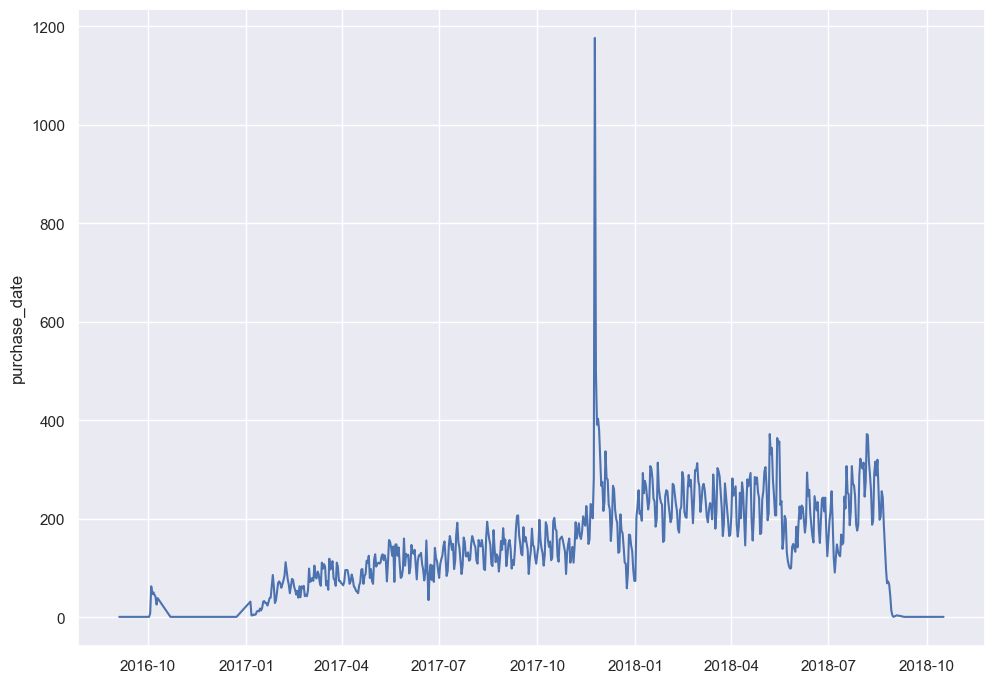

In [80]:
sns.set(rc={'figure.figsize':(11.7,8.27)})
g = sns.lineplot(data=ord_time_dist)

In [81]:
max_date

datetime.date(2018, 10, 17)

In [82]:
ord_df

,order_id,customer_unique_id,total_revenue,freight_value,purchase_date
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,29.99,8.72,2017-10-02
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,118.70,22.76,2018-07-24
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,159.90,19.22,2018-08-08
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,45.00,27.20,2017-11-18
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,19.90,8.72,2018-02-13
...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,6359f309b166b0196dbf7ad2ac62bb5a,72.00,13.08,2017-03-09
99437,63943bddc261676b46f01ca7ac2f7bd8,da62f9e57a76d978d02ab5362c509660,174.90,20.10,2018-02-06
99438,83c1379a015df1e13d02aae0204711ab,737520a9aad80b3fbbdad19b66b37b30,205.99,65.02,2017-08-27
99439,11c177c8e97725db2631073c19f07b62,5097a5312c8b157bb7be58ae360ef43c,359.98,81.18,2018-01-08


In [83]:
# https://practicaldatascience.co.uk/data-science/how-to-assign-rfm-scores-with-quantile-based-discretization
# => Recency is a measure of the number of days since the customer last placed an order. 

### Consolidation Dataframe RFM

In [84]:
df_customers = pd.DataFrame(ord_df['customer_unique_id'].unique())
df_customers.columns = ['customer_unique_id']
df_customers.head()

,customer_unique_id
0,7c396fd4830fd04220f754e42b4e5bff
1,af07308b275d755c9edb36a90c618231
2,3a653a41f6f9fc3d2a113cf8398680e8
3,7c142cf63193a1473d2e66489a9ae977
4,72632f0f9dd73dfee390c9b22eb56dd6


In [85]:
df_recency = ord_df.groupby('customer_unique_id')['purchase_date'].max().reset_index()
df_recency.columns = ['customer_unique_id'
                      ,'recency_date'
                     ]
df_customers = df_customers.merge(df_recency, on='customer_unique_id')
df_customers['recency'] = round((pd.to_datetime('2018-10-17') - pd.to_datetime(df_customers['recency_date']))\
                                / np.timedelta64(1, 'D') ).astype(int)

In [86]:
df_customers

,customer_unique_id,recency_date,recency
0,7c396fd4830fd04220f754e42b4e5bff,2017-10-02,380
1,af07308b275d755c9edb36a90c618231,2018-07-24,85
2,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08,70
3,7c142cf63193a1473d2e66489a9ae977,2017-11-18,333
4,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13,246
...,...,...,...
96091,6359f309b166b0196dbf7ad2ac62bb5a,2017-03-09,587
96092,da62f9e57a76d978d02ab5362c509660,2018-02-06,253
96093,737520a9aad80b3fbbdad19b66b37b30,2017-08-27,416
96094,5097a5312c8b157bb7be58ae360ef43c,2018-01-08,282


In [87]:
### Frequency

# Order frequency is simply the number of orders each customer has placed. 

In [88]:
df_frequency = ord_df.groupby('customer_unique_id')['order_id'].nunique().reset_index()
df_frequency.columns = ['customer_unique_id','frequency']
df_customers = df_customers.merge(df_frequency, on='customer_unique_id')

In [89]:
df_customers

,customer_unique_id,recency_date,recency,frequency
0,7c396fd4830fd04220f754e42b4e5bff,2017-10-02,380,2
1,af07308b275d755c9edb36a90c618231,2018-07-24,85,1
2,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08,70,1
3,7c142cf63193a1473d2e66489a9ae977,2017-11-18,333,1
4,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13,246,1
...,...,...,...,...
96091,6359f309b166b0196dbf7ad2ac62bb5a,2017-03-09,587,1
96092,da62f9e57a76d978d02ab5362c509660,2018-02-06,253,1
96093,737520a9aad80b3fbbdad19b66b37b30,2017-08-27,416,1
96094,5097a5312c8b157bb7be58ae360ef43c,2018-01-08,282,1


In [90]:
### Monetary value

# The monetary value column is the sum() of the total_revenue column for each customer. 

In [91]:
ord_df['total_revenue'].describe()

count    98666.000000
mean       137.754076
std        210.645145
min          0.850000
25%         45.900000
50%         86.900000
75%        149.900000
max      13440.000000
Name: total_revenue, dtype: float64

In [92]:
ord_df['total_revenue'].isna().value_counts()

False    98666
True       775
Name: total_revenue, dtype: int64

In [93]:
# drop orders with no price listed
ord_df.dropna(subset=['total_revenue'], inplace=True)

ord_df['total_revenue'].isna().value_counts()

False    98666
Name: total_revenue, dtype: int64

In [94]:
ord_df

,order_id,customer_unique_id,total_revenue,freight_value,purchase_date
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,29.99,8.72,2017-10-02
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,118.70,22.76,2018-07-24
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,159.90,19.22,2018-08-08
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,45.00,27.20,2017-11-18
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,19.90,8.72,2018-02-13
...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,6359f309b166b0196dbf7ad2ac62bb5a,72.00,13.08,2017-03-09
99437,63943bddc261676b46f01ca7ac2f7bd8,da62f9e57a76d978d02ab5362c509660,174.90,20.10,2018-02-06
99438,83c1379a015df1e13d02aae0204711ab,737520a9aad80b3fbbdad19b66b37b30,205.99,65.02,2017-08-27
99439,11c177c8e97725db2631073c19f07b62,5097a5312c8b157bb7be58ae360ef43c,359.98,81.18,2018-01-08


In [95]:
df_customers

,customer_unique_id,recency_date,recency,frequency
0,7c396fd4830fd04220f754e42b4e5bff,2017-10-02,380,2
1,af07308b275d755c9edb36a90c618231,2018-07-24,85,1
2,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08,70,1
3,7c142cf63193a1473d2e66489a9ae977,2017-11-18,333,1
4,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13,246,1
...,...,...,...,...
96091,6359f309b166b0196dbf7ad2ac62bb5a,2017-03-09,587,1
96092,da62f9e57a76d978d02ab5362c509660,2018-02-06,253,1
96093,737520a9aad80b3fbbdad19b66b37b30,2017-08-27,416,1
96094,5097a5312c8b157bb7be58ae360ef43c,2018-01-08,282,1


In [96]:
df_monetary = ord_df.groupby('customer_unique_id')['total_revenue'].sum().reset_index()
df_monetary.columns = ['customer_unique_id','monetary']

In [97]:
df_monetary['monetary'].describe()

count    95420.000000
mean       142.440198
std        217.656355
min          0.850000
25%         47.900000
50%         89.900000
75%        155.000000
max      13440.000000
Name: monetary, dtype: float64

In [98]:
df_monetary.loc[df_monetary['monetary'] == 0]['customer_unique_id'].nunique()

0

In [99]:
# retrait des customers sans achat
df_monetary.dropna(subset=['monetary'], inplace=True)

In [100]:
mask_value = df_monetary['monetary'] == 0
df_monetary = df_monetary.loc[~mask_value]

In [101]:
df_monetary.describe()

,monetary
count,95420.000000
mean,142.440198
std,217.656355
min,0.850000
25%,47.900000
50%,89.900000
75%,155.000000
max,13440.000000


In [102]:
df_customers = df_customers.merge(df_monetary, on='customer_unique_id')

df_customers.drop(['recency_date'], axis=1, inplace=True)
df_customers

,customer_unique_id,recency,frequency,monetary
0,7c396fd4830fd04220f754e42b4e5bff,380,2,65.38
1,af07308b275d755c9edb36a90c618231,85,1,118.70
2,3a653a41f6f9fc3d2a113cf8398680e8,70,1,159.90
3,7c142cf63193a1473d2e66489a9ae977,333,1,45.00
4,72632f0f9dd73dfee390c9b22eb56dd6,246,1,19.90
...,...,...,...,...
95415,6359f309b166b0196dbf7ad2ac62bb5a,587,1,72.00
95416,da62f9e57a76d978d02ab5362c509660,253,1,174.90
95417,737520a9aad80b3fbbdad19b66b37b30,416,1,205.99
95418,5097a5312c8b157bb7be58ae360ef43c,282,1,359.98


## Product categories

In [103]:
data['order_items']

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


In [104]:
# check product categories
data['product_category_name_translation']

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor
5,esporte_lazer,sports_leisure
6,perfumaria,perfumery
7,utilidades_domesticas,housewares
8,telefonia,telephony
9,relogios_presentes,watches_gifts


In [105]:
# merge into general categories if possible
data['product_category_name_translation']['product_category_name_english'].sort_values(ascending=True).tolist()

['agro_industry_and_commerce',
 'air_conditioning',
 'art',
 'arts_and_craftmanship',
 'audio',
 'auto',
 'baby',
 'bed_bath_table',
 'books_general_interest',
 'books_imported',
 'books_technical',
 'cds_dvds_musicals',
 'christmas_supplies',
 'cine_photo',
 'computers',
 'computers_accessories',
 'consoles_games',
 'construction_tools_construction',
 'construction_tools_lights',
 'construction_tools_safety',
 'cool_stuff',
 'costruction_tools_garden',
 'costruction_tools_tools',
 'diapers_and_hygiene',
 'drinks',
 'dvds_blu_ray',
 'electronics',
 'fashio_female_clothing',
 'fashion_bags_accessories',
 'fashion_childrens_clothes',
 'fashion_male_clothing',
 'fashion_shoes',
 'fashion_sport',
 'fashion_underwear_beach',
 'fixed_telephony',
 'flowers',
 'food',
 'food_drink',
 'furniture_bedroom',
 'furniture_decor',
 'furniture_living_room',
 'furniture_mattress_and_upholstery',
 'garden_tools',
 'health_beauty',
 'home_appliances',
 'home_appliances_2',
 'home_comfort_2',
 'home_confo

### Reduce dimensionality


In [106]:
# initially listed as a reminder to have exhaustive lists, not used
other = [
 'auto',
 'unknown'
 ]

In [107]:
books_stationery =[
 'books_general_interest',
 'books_imported',
 'books_technical',
 'stationery'
]

electronics = [
 'electronics',
 'computers',
 'computers_accessories',
 'dvds_blu_ray',
 'fixed_telephony',
 'telephony',
 'small_appliances',
 'small_appliances_home_oven_and_coffee',
 'tablets_printing_image'
]

construction = [
 'construction_tools_construction',
 'construction_tools_lights',
 'construction_tools_safety',
 'costruction_tools_tools',
 'home_construction'
]

garden = [
 'costruction_tools_garden',
 'garden_tools'
]


fashion = [
 'fashio_female_clothing',
 'fashion_bags_accessories',
 'fashion_childrens_clothes',
 'fashion_male_clothing',
 'fashion_shoes',
 'fashion_sport',
 'fashion_underwear_beach'
]


furniture = [
 'bed_bath_table',
 'furniture_bedroom',
 'furniture_decor',
 'furniture_living_room',
 'furniture_mattress_and_upholstery',
 'office_furniture',
 'kitchen_dining_laundry_garden_furniture',
 'la_cuisine'
]

health_beauty = [
 'health_beauty',
 'perfumery',
 'baby',
 'diapers_and_hygiene'
]

home = [
 'home_appliances',
 'home_appliances_2',
 'home_comfort_2',
 'home_confort',
 'housewares',
 'flowers',
 'christmas_supplies',
 'party_supplies'
]


toys_gifts = [
 'toys',
 'watches_gifts',
 'cool_stuff'
]

sports_leisure = [
 'sports_leisure',
 'cine_photo',
 'musical_instruments',
 'art',
 'arts_and_craftmanship',
 'cds_dvds_musicals',
 'music',
 'consoles_games',
 'audio'
]

misc = [
 'agro_industry_and_commerce',
 'air_conditioning',
 'industry_commerce_and_business',
 'luggage_accessories',
 'market_place',
 'pet_shop',
 'security_and_services',
 'signaling_and_security',
 'drinks',
 'food',
 'food_drink'
 ]



In [108]:
product_names["product_global_category"] = product_names["product_category_name_english"]

In [109]:
product_names['product_global_category'] = product_names['product_global_category'].replace(books_stationery, 'books_stationery')
product_names['product_global_category'] = product_names['product_global_category'].replace(electronics, 'electronics')
product_names['product_global_category'] = product_names['product_global_category'].replace(construction, 'construction')
product_names['product_global_category'] = product_names['product_global_category'].replace(garden, 'garden')
product_names['product_global_category'] = product_names['product_global_category'].replace(fashion, 'fashion')
product_names['product_global_category'] = product_names['product_global_category'].replace(furniture, 'furniture')
product_names['product_global_category'] = product_names['product_global_category'].replace(health_beauty, 'health_beauty')
product_names['product_global_category'] = product_names['product_global_category'].replace(home, 'home')
product_names['product_global_category'] = product_names['product_global_category'].replace(toys_gifts, 'toys_gifts')
product_names['product_global_category'] = product_names['product_global_category'].replace(sports_leisure, 'sports_leisure')
product_names['product_global_category'] = product_names['product_global_category'].replace(misc, 'misc')

In [110]:
product_names['product_global_category'].nunique()

13

In [111]:
product_names['product_global_category'].unique().tolist()

['health_beauty',
 'electronics',
 'auto',
 'furniture',
 'sports_leisure',
 'home',
 'toys_gifts',
 'misc',
 'books_stationery',
 'garden',
 'fashion',
 'construction',
 'unknown']

In [112]:
product_names['product_global_category'].value_counts()

misc                11
electronics          9
sports_leisure       9
furniture            8
home                 8
fashion              7
construction         5
health_beauty        4
books_stationery     4
toys_gifts           3
garden               2
auto                 1
unknown              1
Name: product_global_category, dtype: int64

In [113]:
# merge

In [114]:
products

,product_id,product_category_name,product_category_name_english,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,perfumery,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,art,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,sports_leisure,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,baby,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,housewares,37.0,402.0,4.0,625.0,20.0,17.0,13.0
...,...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,furniture_decor,45.0,67.0,2.0,12300.0,40.0,40.0,40.0
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,construction_tools_lights,41.0,971.0,1.0,1700.0,16.0,19.0,16.0
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,bed_bath_table,50.0,799.0,1.0,1400.0,27.0,7.0,27.0
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,computers_accessories,60.0,156.0,2.0,700.0,31.0,13.0,20.0


In [115]:
product_names

,product_category_name,product_category_name_english,product_global_category
0,beleza_saude,health_beauty,health_beauty
1,informatica_acessorios,computers_accessories,electronics
2,automotivo,auto,auto
3,cama_mesa_banho,bed_bath_table,furniture
4,moveis_decoracao,furniture_decor,furniture
5,esporte_lazer,sports_leisure,sports_leisure
6,perfumaria,perfumery,health_beauty
7,utilidades_domesticas,housewares,home
8,telefonia,telephony,electronics
9,relogios_presentes,watches_gifts,toys_gifts


In [116]:
data['products']['product_category_name'].value_counts()

cama_mesa_banho                                   3029
esporte_lazer                                     2867
moveis_decoracao                                  2657
beleza_saude                                      2444
utilidades_domesticas                             2335
automotivo                                        1900
informatica_acessorios                            1639
brinquedos                                        1411
relogios_presentes                                1329
telefonia                                         1134
bebes                                              919
perfumaria                                         868
fashion_bolsas_e_acessorios                        849
papelaria                                          849
cool_stuff                                         789
ferramentas_jardim                                 753
pet_shop                                           719
unknown                                            610
eletronico

In [117]:
products = products.merge(product_names[['product_category_name_english', 'product_global_category']], on='product_category_name_english' ,how='left')

In [118]:
product_cols_order = ['product_id',
 'product_category_name',
 'product_category_name_english',
 'product_global_category',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm']

In [119]:
products = products.reindex(product_cols_order, axis=1)

In [120]:
#products['product_category_name_english'].value_counts()
#products['product_category_name_english'].value_counts().sort_index(ascending=True)

In [121]:
products.head()

,product_id,product_category_name,product_category_name_english,product_global_category,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,perfumery,health_beauty,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,art,sports_leisure,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,sports_leisure,sports_leisure,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,baby,health_beauty,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,housewares,home,37.0,402.0,4.0,625.0,20.0,17.0,13.0


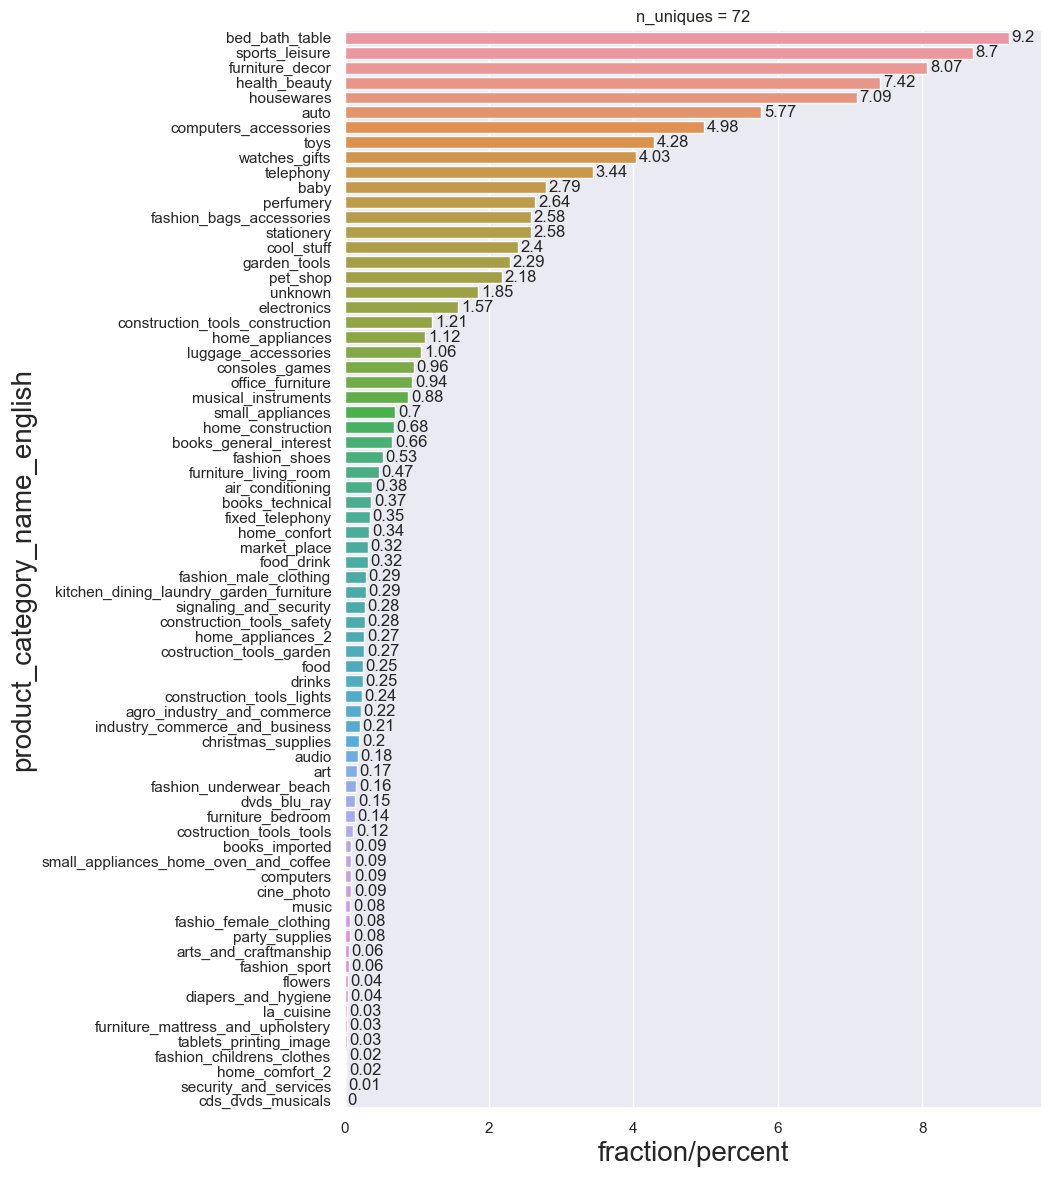

In [122]:
UVA.category(products, ['product_category_name_english'], 9, 14)

### process by customer

In [123]:
#ord_df.head()

In [124]:
#products.head()

In [125]:
#matching_table.head()

In [126]:
custo_product = matching_table[['customer_unique_id', 'product_id']]\
    .merge(products[['product_id', 'product_global_category']], on='product_id', how='inner')
custo_product.head()

,customer_unique_id,product_id,product_global_category
0,7c396fd4830fd04220f754e42b4e5bff,87285b34884572647811a353c7ac498a,home
1,3a51803cc0d012c3b5dc8b7528cb05f7,87285b34884572647811a353c7ac498a,home
2,ef0996a1a279c26e7ecbd737be23d235,87285b34884572647811a353c7ac498a,home
3,e781fdcc107d13d865fc7698711cc572,87285b34884572647811a353c7ac498a,home
4,02c9e0c05a817d4562ec0e8c90f29dba,b00a32a0b42fd65efb58a5822009f629,health_beauty


In [127]:
# check custo_product nans
custo_product.isna().sum()

customer_unique_id          0
product_id                  0
product_global_category    24
dtype: int64

In [128]:
custo_product.loc[custo_product['product_global_category'].isna()]

,customer_unique_id,product_id,product_global_category
56408,ef3210ff1b594a76939d1b3686e7fd02,c7a3f1a7f9eef146cc499368b578b884,NaN
56409,81a79f384f8602573644b70698bab3b1,c7a3f1a7f9eef146cc499368b578b884,NaN
56410,c283a677fa9937143f13fe6f58fd901d,c7a3f1a7f9eef146cc499368b578b884,NaN
58197,949921a7831eb8901f75baf57d1853bf,0105b5323d24fc655f73052694dbbb3a,NaN
58198,11b47516f8f6a42105b9807903ede333,0105b5323d24fc655f73052694dbbb3a,NaN
58199,28d9650a4a5f00fcc716da5ee2460012,0105b5323d24fc655f73052694dbbb3a,NaN
58200,b25c62ba4fc28e41117f8026bf9a31b5,0105b5323d24fc655f73052694dbbb3a,NaN
58201,b70d126df03b594cb148da07860d1534,0105b5323d24fc655f73052694dbbb3a,NaN
76089,24a0683609e642fe0d86e5e2c97712f5,1954739d84629e7323a4295812a3e0ec,NaN
76093,f7f16795a1871264c01bd5464a30b437,a4756663d007b0cd1af865754d08d968,NaN


In [129]:
# fill the 24 lines with NaN global categories : unknown
custo_product['product_global_category'].fillna("unknown", inplace=True)
custo_product['product_global_category'].isnull().value_counts()

False    113314
Name: product_global_category, dtype: int64

In [130]:
#custo_product.groupby(['customer_unique_id', 'product_global_category']).size().reset_index(name="counts")

In [131]:
df_cus_cat = custo_product[['customer_unique_id', 'product_global_category']].value_counts().reset_index(name="counts")
df_cus_cat.head()

,customer_unique_id,product_global_category,counts
0,c8460e4251689ba205045f3ea17884a1,electronics,24
1,d97b3cfb22b0d6b25ac9ed4e9c2d481b,furniture,24
2,4546caea018ad8c692964e3382debd19,health_beauty,21
3,c402f431464c72e27330a67f7b94d4fb,electronics,20
4,698e1cf81d01a3d389d96145f7fa6df8,auto,20


In [132]:
custo_product

,customer_unique_id,product_id,product_global_category
0,7c396fd4830fd04220f754e42b4e5bff,87285b34884572647811a353c7ac498a,home
1,3a51803cc0d012c3b5dc8b7528cb05f7,87285b34884572647811a353c7ac498a,home
2,ef0996a1a279c26e7ecbd737be23d235,87285b34884572647811a353c7ac498a,home
3,e781fdcc107d13d865fc7698711cc572,87285b34884572647811a353c7ac498a,home
4,02c9e0c05a817d4562ec0e8c90f29dba,b00a32a0b42fd65efb58a5822009f629,health_beauty
...,...,...,...
113309,2077f7ec37df79c62cc24b7b8f30e8c9,31ec3a565e06de4bdf9d2a511b822b4d,construction
113310,78a159045124eb7601951b917a42034f,241a1ffc9cf969b27de6e72301020268,auto
113311,8cf3c6e1d2c8afaab2eda3fa01d4e3d2,1d187e8e7a30417fda31e85679d96f0f,furniture
113312,e55e436481078787e32349cee9febf5e,6e1c2008dea1929b9b6c27fa01381e90,furniture


#### feature variance filtering

##### prepare monetary values per customer on categories

In [133]:
# TODO pivot and merge all categories details
df_cus_cat_pivot = df_cus_cat.pivot_table(index=['customer_unique_id']
                                            ,columns='product_global_category'
                                            ,values='counts'
                                           )\
                    .reset_index()\
                    .rename_axis(None, axis=1)\
                    .fillna(0)
# unstack('product_global_category')
pivot_num_cols = df_cus_cat_pivot.select_dtypes(include=np.number).columns.to_list()
df_cus_cat_pivot[pivot_num_cols] = df_cus_cat_pivot[pivot_num_cols].astype(np.int64)
df_cus_cat_pivot

,customer_unique_id,auto,books_stationery,construction,electronics,fashion,furniture,garden,health_beauty,home,misc,sports_leisure,toys_gifts,unknown
0,0000366f3b9a7992bf8c76cfdf3221e2,0,0,0,0,0,1,0,0,0,0,0,0,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,0,0,0,0,0,0,0,1,0,0,0,0,0
2,0000f46a3911fa3c0805444483337064,0,1,0,0,0,0,0,0,0,0,0,0,0
3,0000f6ccb0745a6a4b88665a16c9f078,0,0,0,1,0,0,0,0,0,0,0,0,0
4,0004aac84e0df4da2b147fca70cf8255,0,0,0,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95415,fffcf5a5ff07b0908bd4e2dbc735a684,0,0,0,0,0,0,0,2,0,0,0,0,0
95416,fffea47cd6d3cc0a88bd621562a9d061,0,0,0,0,0,0,0,1,0,0,0,0,0
95417,ffff371b4d645b6ecea244b27531430a,1,0,0,0,0,0,0,0,0,0,0,0,0
95418,ffff5962728ec6157033ef9805bacc48,0,0,0,0,0,0,0,0,0,0,0,1,0


In [134]:
# change focus : monetary value per sub-category rather than order count per main category :

In [135]:
custo_product_all_cat = matching_table[['customer_unique_id', 'product_id', 'price']]\
    .merge(products[['product_id', 'product_category_name_english']], on='product_id', how='inner')
custo_product_all_cat.head()

,customer_unique_id,product_id,price,product_category_name_english
0,7c396fd4830fd04220f754e42b4e5bff,87285b34884572647811a353c7ac498a,29.99,housewares
1,3a51803cc0d012c3b5dc8b7528cb05f7,87285b34884572647811a353c7ac498a,29.99,housewares
2,ef0996a1a279c26e7ecbd737be23d235,87285b34884572647811a353c7ac498a,29.99,housewares
3,e781fdcc107d13d865fc7698711cc572,87285b34884572647811a353c7ac498a,29.99,housewares
4,02c9e0c05a817d4562ec0e8c90f29dba,b00a32a0b42fd65efb58a5822009f629,75.90,baby


In [136]:
custo_product_all_cat.isna().sum()

customer_unique_id                0
product_id                        0
price                             0
product_category_name_english    24
dtype: int64

In [137]:
matching_table.duplicated().sum()

0

In [138]:
custo_product_all_cat.duplicated().sum()

11241

In [139]:
custo_product_all_cat[custo_product_all_cat.duplicated()]

,customer_unique_id,product_id,price,product_category_name_english
10,8cafc4a24a917c4a9084b763a82baf66,b00a32a0b42fd65efb58a5822009f629,79.90,baby
79,958ac7760e5484df1496ba5833ab6117,595fac2a385ac33a80bd5114aec74eb8,116.90,perfumery
90,f5985137de910a1e58ed6bc3214a4100,595fac2a385ac33a80bd5114aec74eb8,116.90,perfumery
115,60a1e88691ef46c62b52fb2b994d7675,595fac2a385ac33a80bd5114aec74eb8,117.90,perfumery
121,7dd163b8e3d4e09daa9e16091dd6dd26,595fac2a385ac33a80bd5114aec74eb8,119.90,perfumery
...,...,...,...,...
113287,803c530613f5c4ee03502be0d6894de0,0c40401eba358c9ef2ff2df80b6eab52,41.33,unknown
113288,803c530613f5c4ee03502be0d6894de0,0c40401eba358c9ef2ff2df80b6eab52,41.33,unknown
113292,a38640e92b9b5084cad12f3f3b200a83,6292e8c74db1d4defdbd8244c1101bb6,23.90,perfumery
113306,0b39f417a3c099ff0497346258e8d752,710e8b076db06c8e5343a9e23f0e3d83,44.99,sports_leisure


In [140]:
custo_product_all_cat.drop_duplicates(inplace=True)
print(custo_product_all_cat.duplicated().sum())
print(custo_product_all_cat.shape)

0
(102073, 4)


In [141]:
# agg per customer_unique_id : total sum/price per category
all_cat_monetary = custo_product_all_cat.groupby(['customer_unique_id', 'product_category_name_english'])['price'].sum().reset_index()
all_cat_monetary

,customer_unique_id,product_category_name_english,price
0,0000366f3b9a7992bf8c76cfdf3221e2,bed_bath_table,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,health_beauty,18.90
2,0000f46a3911fa3c0805444483337064,stationery,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,telephony,25.99
4,0004aac84e0df4da2b147fca70cf8255,telephony,180.00
...,...,...,...
97888,fffcf5a5ff07b0908bd4e2dbc735a684,health_beauty,1570.00
97889,fffea47cd6d3cc0a88bd621562a9d061,baby,64.89
97890,ffff371b4d645b6ecea244b27531430a,auto,89.90
97891,ffff5962728ec6157033ef9805bacc48,watches_gifts,115.00


In [142]:
df_cus_all_cat_pivot = all_cat_monetary.pivot_table(index=['customer_unique_id']
                                            ,columns='product_category_name_english'
                                            ,values='price'
                                           )\
                    .rename_axis(None, axis=1)\
                    .fillna(0)
df_cus_all_cat_pivot

,agro_industry_and_commerce,air_conditioning,art,arts_and_craftmanship,audio,auto,baby,bed_bath_table,books_general_interest,books_imported,books_technical,cds_dvds_musicals,christmas_supplies,cine_photo,computers,computers_accessories,consoles_games,construction_tools_construction,construction_tools_lights,construction_tools_safety,cool_stuff,costruction_tools_garden,costruction_tools_tools,diapers_and_hygiene,drinks,dvds_blu_ray,electronics,fashio_female_clothing,fashion_bags_accessories,fashion_childrens_clothes,fashion_male_clothing,fashion_shoes,fashion_sport,fashion_underwear_beach,fixed_telephony,flowers,food,food_drink,furniture_bedroom,furniture_decor,furniture_living_room,furniture_mattress_and_upholstery,garden_tools,health_beauty,home_appliances,home_appliances_2,home_comfort_2,home_confort,home_construction,housewares,industry_commerce_and_business,kitchen_dining_laundry_garden_furniture,la_cuisine,luggage_accessories,market_place,music,musical_instruments,office_furniture,party_supplies,perfumery,pet_shop,security_and_services,signaling_and_security,small_appliances,small_appliances_home_oven_and_coffee,sports_leisure,stationery,tablets_printing_image,telephony,toys,unknown,watches_gifts
customer_unique_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,0.0,0.0,0.0,0.0,0.0,0.0,0.00,129.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0
0000b849f77a49e4a4ce2b2a4ca5be3f,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0
0000f46a3911fa3c0805444483337064,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,69.0,0.0,0.00,0.0,0.0,0.0
0000f6ccb0745a6a4b88665a16c9f078,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.99,0.0,0.0,0.0
0004aac84e0df4da2b147fca70cf8255,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,180.00,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
fffcf5a5ff07b0908bd4e2dbc735a684,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1570.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0
fffea47cd6d3cc0a88bd621562a9d061,0.0,0.0,0.0,0.0,0.0,0.0,64.89,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0
ffff371b4d645b6ecea244b27531430a,0.0,0.0,0.0,0.0,0.0,89.9,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.

In [143]:
print(df_cus_all_cat_pivot.isna().sum().sum())
print(df_cus_all_cat_pivot.duplicated().sum())

0
74187


##### apply low variance filter

In [144]:
# https://datacorner.fr/feature-variance-filtering/
# https://medium.com/analytics-vidhya/dimensionality-reduction-in-machine-learning-feature-selection-69341419872a

In [145]:
#df_cus_all_cat_pivot.set_index('customer_unique_id', inplace=True)
#df_cus_all_cat_pivot.reset_index()

In [ ]:
pivot_num_cols = df_cus_all_cat_pivot.select_dtypes(include=np.number).columns.to_list()
#MVA.boxplot_nums(df_cus_all_cat_pivot, pivot_num_cols)

In [ ]:
df_cus_all_cat_pivot.shape[1] / 6

In [162]:
ax_coord = [(i,j) for i in range(0,12) for j in range(0,6)]
cols_list = df_cus_all_cat_pivot.columns
len(cols_list)

72

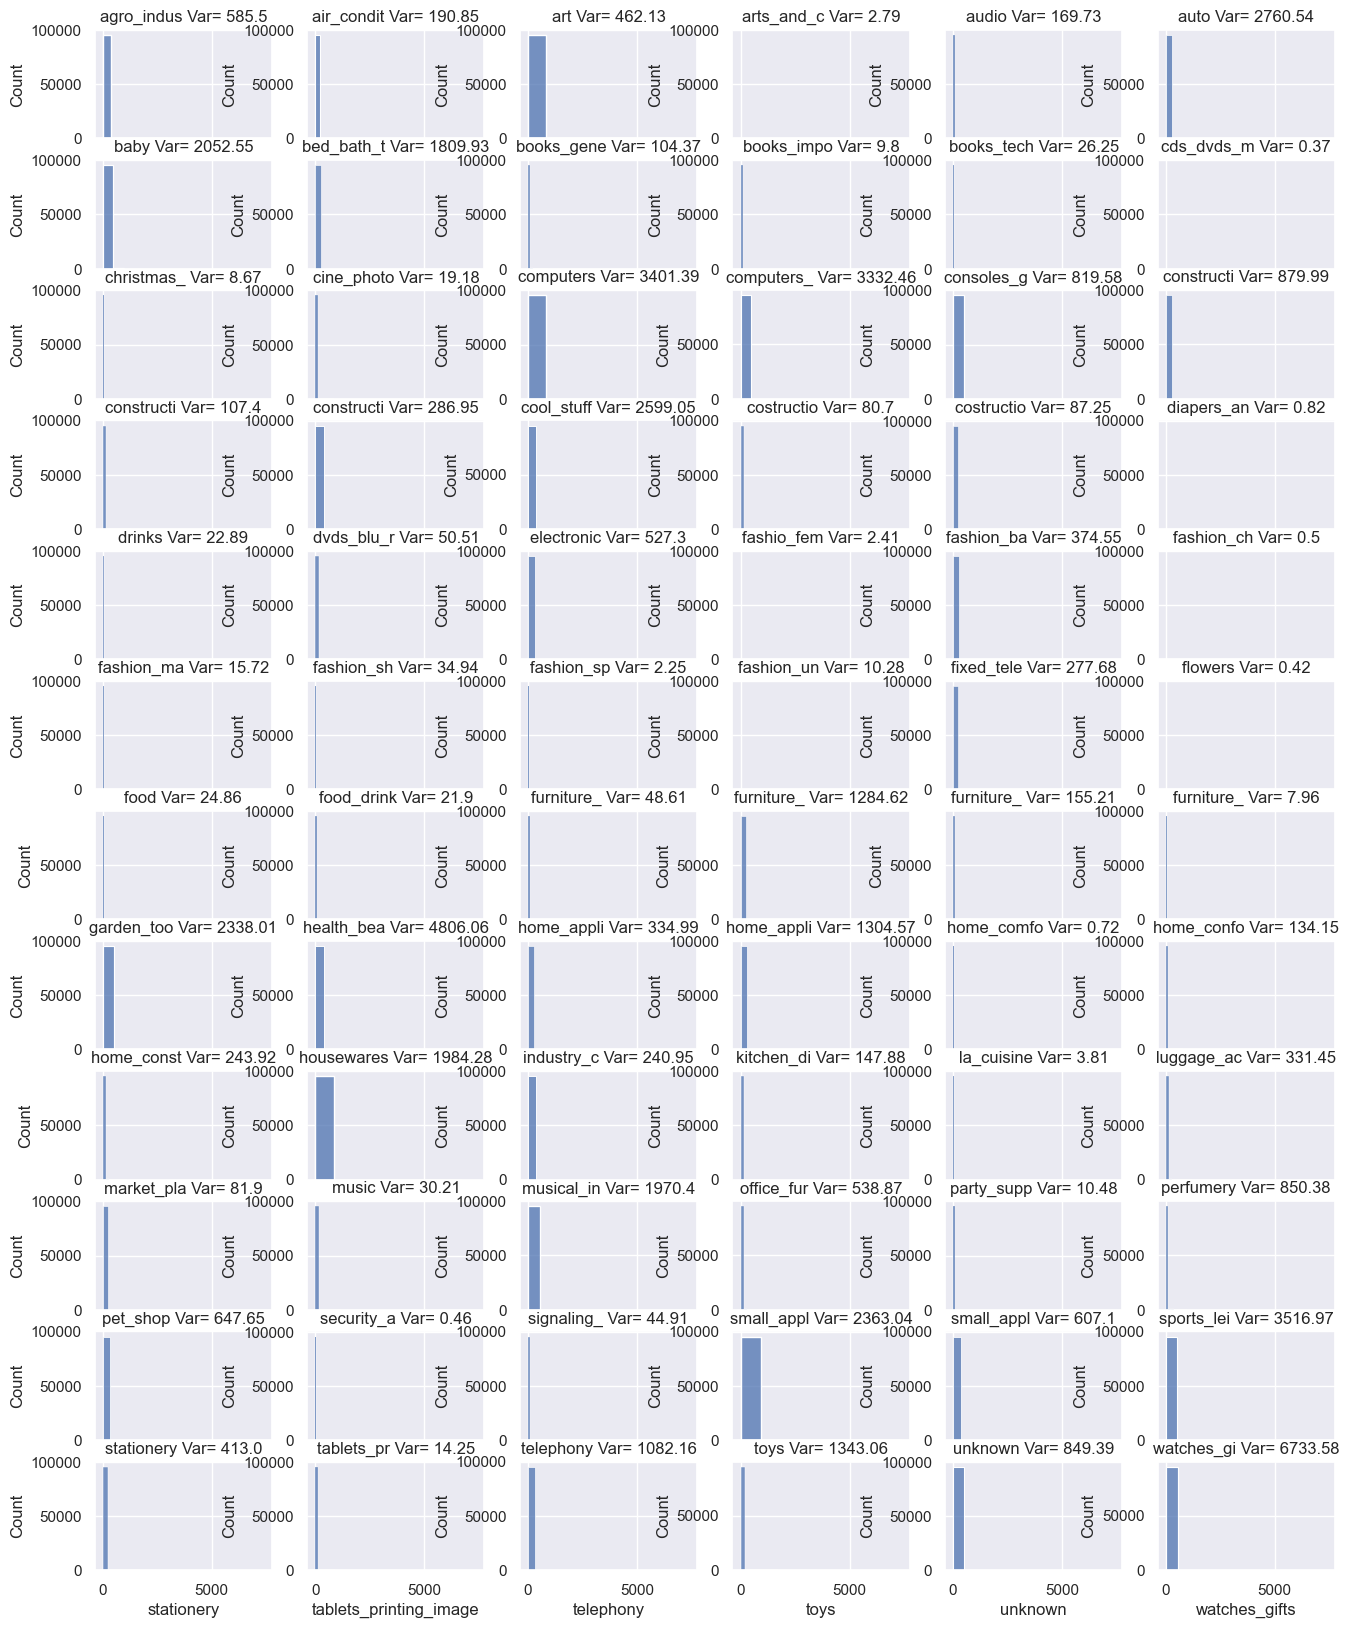

In [196]:
fig, ax = plt.subplots(12, 6, sharex=True, figsize=(16, 20))
i = 0
for col in cols_list:
    sns.histplot(data=df_cus_all_cat_pivot, x=col, ax=ax[ax_coord[i]], bins=8)
    ax[ax_coord[i]].set_title(col[0:10] + ' Var= ' + str(round(np.var(df_cus_all_cat_pivot[col]), 2)))
    i+=1

In [200]:
# put variance info into readable dataframe :
dict_info = {"feature": []
            ,"variance": []
}

for col in cols_list:
    dict_info["feature"].append(str(col)) 
    dict_info["variance"].append(np.var(df_cus_all_cat_pivot[col]))
    
variance_info = pd.DataFrame.from_dict(dict_info)

In [ ]:
variance_info

In [197]:
for col in cols_list:
  print("Variance for feature ", str(col), ": ", np.var(df_cus_all_cat_pivot[col]))

Variance for feature  agro_industry_and_commerce :  585.5002815495525
Variance for feature  air_conditioning :  190.85252651067987
Variance for feature  art :  462.1270626170087
Variance for feature  arts_and_craftmanship :  2.7905183403926426
Variance for feature  audio :  169.73157977523235
Variance for feature  auto :  2760.5448901170025
Variance for feature  baby :  2052.5508221230175
Variance for feature  bed_bath_table :  1809.9325394207333
Variance for feature  books_general_interest :  104.37277949288665
Variance for feature  books_imported :  9.801883014059467
Variance for feature  books_technical :  26.25181137150886
Variance for feature  cds_dvds_musicals :  0.3699759591085094
Variance for feature  christmas_supplies :  8.667298874493317
Variance for feature  cine_photo :  19.177895492691462
Variance for feature  computers :  3401.393278535142
Variance for feature  computers_accessories :  3332.464185129068
Variance for feature  consoles_games :  819.5817099162512
Variance f

In [ ]:
vt = VarianceThreshold() # Threshold default is 0
_ = vt.fit(dataset)
var_vector_mask = vt.get_support()
var_vector_mask 

#### Main cat per customer

In [ ]:
idx = df_cus_cat.groupby(['customer_unique_id'])['product_global_category','counts'].idxmax()
#max_counts = df_cus_cat[idx]

In [ ]:
idx = df_cus_cat.groupby('customer_unique_id')['counts'].idxmax()

In [ ]:
cus_cat_max = df_cus_cat[df_cus_cat.index.isin(idx)]
cus_cat_max

In [ ]:
df_cus_cat['customer_unique_id'].value_counts()

In [ ]:
df_cus_cat.loc[df_cus_cat['customer_unique_id'] == '3e43e6105506432c953e165fb2acf44c']

In [ ]:
cus_cat_max.loc[cus_cat_max['customer_unique_id'] == '8c21dd8c37144807c601f99f2a209dfb']

In [ ]:
cus_cat_max.rename(columns={"product_global_category":"main_category"}, inplace=True)
cus_cat_max

In [ ]:
# merge max_category into
df_customers = df_customers.merge(cus_cat_max[['customer_unique_id', 'main_category']], on='customer_unique_id', how='left')
df_customers

In [ ]:
#UVA.category(products, ['product_global_category'], 9, 5)

In [ ]:
df_cus_cat

In [ ]:
# TODO pivot and merge all categories details
df_cus_cat_pivot = df_cus_cat.pivot_table(index=['customer_unique_id']
                                            ,columns='product_global_category'
                                            ,values='counts'
                                           )\
                    .reset_index()\
                    .rename_axis(None, axis=1)\
                    .fillna(0)
# unstack('product_global_category')
pivot_num_cols = df_cus_cat_pivot.select_dtypes(include=np.number).columns.to_list()
df_cus_cat_pivot[pivot_num_cols] = df_cus_cat_pivot[pivot_num_cols].astype(np.int64)
df_cus_cat_pivot

## Freight value

In [ ]:
df_freight_value = ord_df.groupby('customer_unique_id')['freight_value'].sum().reset_index()
df_freight_value

In [ ]:
df_customers = df_customers.merge(df_freight_value, on='customer_unique_id')
df_customers

In [ ]:
df_customers.isna().sum()

In [ ]:
num_cols = df_customers.select_dtypes(include=np.number).columns.to_list()
MVA.boxplot_nums(df_customers, num_cols)

### weight / length / heigh / width

In [ ]:
products.isna().sum()

In [ ]:
prod_cols = ['product_id', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
prod_num_cols = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

In [ ]:
products[prod_cols]

In [ ]:
matching_table = matching_table.merge(products[prod_cols], on='product_id', how='outer')

=> We will focus on **product_weight_g / product_length_cm / product_height_cm / product_width_cm** which only has 2 null values

In [ ]:
product_mean = matching_table.groupby('customer_unique_id')[prod_num_cols].mean().reset_index()
product_mean.rename(columns={"product_weight_g":"product_weight_mean" ,"product_length_cm":"product_length_mean", "product_height_cm":"product_height_mean", "product_width_cm": "product_width_mean"}, inplace=True)
product_mean

In [ ]:
product_mean.isna().sum()

In [ ]:
product_mean.duplicated().sum()

In [ ]:
product_mean.shape

In [ ]:
df_customers.shape

In [ ]:
product_mean.columns.tolist()

In [ ]:
prod_mean_cols = ['product_weight_mean','product_length_mean','product_height_mean','product_width_mean']
MVA.boxplot_nums(product_mean, prod_mean_cols)

In [ ]:
df_customers = df_customers.merge(product_mean, on='customer_unique_id')
df_customers

In [ ]:
df_customers.isna().sum()

In [ ]:
dim_ukno_df = df_customers[df_customers['product_weight_mean'].isna()]
dim_ukno_df

In [ ]:
df_customers.drop(index = 37542, inplace=True)

In [ ]:
dim_ukno_df[dim_ukno_df.main_category == 'unknown'][['monetary']].mean()

In [ ]:
df_customers[(df_customers['frequency'] == 1)\
             & (df_customers['monetary'].between(29, 58))\
             & (df_customers['main_category'] == 'unknown')]\
[prod_mean_cols]\
.median()

In [ ]:
df_customers['product_weight_mean'].isna().sum()

In [ ]:
df_customers['product_weight_mean'].fillna(400,inplace=True)
df_customers['product_length_mean'].fillna(24,inplace=True)
df_customers['product_height_mean'].fillna(11,inplace=True)
df_customers['product_width_mean'].fillna(15,inplace=True)

In [ ]:
df_customers.isna().sum()

In [ ]:
MVA.heatmap_num_2(df_customers)

In [ ]:
# length / height / width highly correlated => merge into one "product_volume_mean" variable


In [ ]:
df_customers.head()

In [ ]:
df_customers['product_volume_mean'] = df_customers.product_length_mean * df_customers.product_width_mean\
                                * df_customers.product_height_mean
df_customers.drop(columns=['product_length_mean', 'product_width_mean', 'product_height_mean'], inplace=True)
df_customers

In [ ]:
MVA.heatmap_num_2(df_customers)

## Sellers

In [ ]:
sellers.head()

In [ ]:
sellers.isna().sum()

In [ ]:
sellers.duplicated().sum()

In [ ]:
sellers['seller_id'].duplicated().sum()

In [ ]:
matching_table

In [ ]:
matching_table.columns.tolist()

In [ ]:
df_sellers_count = matching_table.groupby('customer_unique_id')['seller_id'].nunique().reset_index()
df_sellers_count.columns = ['customer_unique_id','sellers_count']

In [ ]:
ax = sns.histplot(df_sellers_count['sellers_count'])

In [ ]:
# qcut / cut ?

In [ ]:
df_customers = df_customers.merge(df_sellers_count, on='customer_unique_id')
df_customers

In [ ]:
df_customers.isna().sum()

## Most frequently bought categories

### main categories

In [ ]:
## redundant ?

## Reviews info

### percent review score shared

In [ ]:
matching_table.columns.to_list()

In [ ]:
ord_df.head()

In [ ]:
reviews.head()

In [ ]:
# check reviews

In [ ]:
reviews.isna().sum()

In [ ]:
score_list = reviews['review_score'].unique().tolist()
score_list.sort()
score_list

In [ ]:
reviews['review_score'].dtype

In [ ]:
sns.histplot(reviews, x='review_score', shrink=15)

In [ ]:
# join/merge tables
custo_reviews = matching_table[['customer_unique_id', 'order_id', 'review_id']]\
            .merge(reviews[['review_id', 'review_score', 'review_comment_message']], on = 'review_id', how='inner')
custo_reviews.head()

In [ ]:
custo_reviews.shape

In [ ]:
mean_review_score = custo_reviews.groupby(['customer_unique_id'])['review_score'].mean().reset_index()
mean_review_score.rename(columns={"review_score":"mean_review_score"}, inplace=True)
mean_review_score

In [ ]:
# check result with customer having multiple orders/reviews => float ?
mean_review_score.loc[mean_review_score['customer_unique_id'] == '3e43e6105506432c953e165fb2acf44c']

In [ ]:
mean_review_score['mean_review_score'].isna().sum()

In [ ]:
# merge mean_review_score into
df_customers = df_customers.merge(mean_review_score[['customer_unique_id', 'mean_review_score']], on='customer_unique_id', how='left')
df_customers.head()

In [ ]:
# check nans
df_customers.loc[df_customers['mean_review_score'].isna()]

In [ ]:
# other infos are interesting, inputing mean review score by category to complete

# matching each order main category and review score
product_review = matching_table[['customer_unique_id', 'product_id', 'review_id']]\
    .merge(products[['product_id', 'product_global_category']], on='product_id', how='inner')\
    .merge(reviews[['review_id', 'review_score']])
product_review

In [ ]:
product_review['product_global_category'].isna().sum()

In [ ]:
product_review['product_global_category'].fillna("unknown", inplace=True)

In [ ]:
group_cat = product_review.groupby(by='product_global_category')

In [ ]:
mean_review_category = product_review.groupby(by='product_global_category')['review_score'].mean()
mean_review_category

In [ ]:
# inputing to df_customers with missing review score : the overall mean review score by category
df_customers['mean_review_score'] = group_cat['review_score'].transform(lambda x: x.fillna(x.mean()))

In [ ]:
df_customers

In [ ]:
# check nans
df_customers['mean_review_score'].isna().sum()

In [ ]:
sns.histplot(df_customers, x='mean_review_score', shrink=15)

### percent written review made

In [ ]:
custo_reviews['has_comment_message'] = custo_reviews['review_comment_message']
custo_reviews.head()

In [ ]:
# count percent of na message per customer_unique_id
ratio_text_review = custo_reviews.groupby('customer_unique_id')['review_comment_message']\
                .apply(lambda x: x.notnull().sum()/len(x)*100).reset_index()

ratio_text_review.head()

In [ ]:
ratio_text_review.shape

In [ ]:
custo_reviews['customer_unique_id'].shape

In [ ]:
df_customers = df_customers.merge(ratio_text_review, on='customer_unique_id', how='left')
df_customers.head()

In [ ]:
df_customers.shape

In [ ]:
# check and handle NaN
df_customers.isna().sum()

In [ ]:
df_customers[df_customers['review_comment_message'].isna()]

In [ ]:
# other infos for the concerned rows is valuable, 
# NaN here means that the concerned customer_unique_id weren't present in the reviews dataframe
# => insert value 0


In [ ]:
df_customers['review_comment_message'].fillna(0, inplace=True)
df_customers.rename(columns={"review_comment_message":"ratio_comment_message"}, inplace=True)
df_customers

In [ ]:
df_customers[df_customers['customer_unique_id'] == '528b011eb7fab3d59c336cc7248eed3a']

In [ ]:
df_customers.shape

In [ ]:
df_customers.isna().sum()

In [ ]:
df_customers['ratio_comment_message'].value_counts(normalize=True).sort_index(ascending=False)

In [ ]:
sns.histplot(df_customers, x='ratio_comment_message', kde=True)

## Payment methods

In [ ]:
payments = data['order_payments']

In [ ]:
orders

In [ ]:
payments

In [ ]:
matching_table.columns.to_list()

In [ ]:
payments.merge(matching_table[['customer_unique_id', 'order_id']], on='order_id', how='inner')

In [ ]:
payments_custo = payments.merge(matching_table[['customer_unique_id', 'order_id']], on='order_id', how='left')
payments_custo

In [ ]:
payments.describe()

In [ ]:
payments_custo.describe()

In [ ]:
#payments = matching_table[['customer_unique_id', 'order_id', 'product_id', 'review_id']]\
#    .merge(products[['product_id', 'product_global_category']], on='product_id', how='inner')\
#    .merge(reviews[['review_id', 'review_score']])
#payments

In [ ]:
payments

In [ ]:
UVA.category(payments, ['payment_type'], 9, 5)

In [ ]:
payments['payment_type'].isin(['credit_card']).sum()

In [ ]:
# count percent of na message per customer_unique_id
ratio_credit_card = payments_custo.groupby('customer_unique_id')['payment_type']\
                .apply(lambda x: x.isin(['credit_card']).sum()/len(x)*100).reset_index()
ratio_credit_card.rename({'payment_type':'ratio_credit_card'}, axis='columns', inplace=True)

ratio_credit_card.head()

In [ ]:
ratio_credit_card['ratio_credit_card'].value_counts(normalize=True).sort_index(ascending=False)

In [ ]:
sns.histplot(ratio_credit_card, x='ratio_credit_card', kde=True)

In [ ]:
df_customers = df_customers.merge(ratio_credit_card, on='customer_unique_id', how='left')
df_customers.head()

In [ ]:
#check + handling nulls
df_customers.isna().sum()

In [ ]:
df_customers.head()

In [ ]:
df_customers[df_customers['ratio_credit_card'].isna()]

In [ ]:
# only 1 to input, check most frequent ratio_credit_card for frequency == 1 & monetary > 100
df_customers[(df_customers['frequency'] == 1) & (df_customers['monetary'] > 100) & (df_customers['main_category'] == 'health_beauty')]\
['ratio_credit_card'].value_counts(normalize=True).sort_index(ascending=False)

In [ ]:
df_customers['ratio_credit_card'].fillna(100, inplace=True)

print(df_customers.shape)
print(df_customers.isna().sum())

### median payment installments per user :

In [ ]:
sns.histplot(payments, x='payment_installments', kde=True)

In [ ]:
med_pay_install = payments_custo.groupby('customer_unique_id')['payment_installments']\
                .mean().reset_index()
med_pay_install.rename({'payment_installments':'mean_pay_installments'}, axis='columns', inplace=True)

print(med_pay_install.shape)
med_pay_install.head()

In [ ]:
payments_custo.loc[payments_custo['customer_unique_id'] == 'fffcf5a5ff07b0908bd4e2dbc735a684']

In [ ]:
med_pay_install.loc[med_pay_install['customer_unique_id'] == 'fffcf5a5ff07b0908bd4e2dbc735a684']

In [ ]:
# insert into df_customers
df_customers = df_customers.merge(med_pay_install, on='customer_unique_id', how='left')
df_customers.head()

In [ ]:
df_customers.isna().sum()

In [ ]:
#handle missing data
df_customers[df_customers['mean_pay_installments'].isna()]

In [ ]:
# only 1 to input, check most frequent ratio_credit_card for frequency == 1 & monetary > 100
df_customers[(df_customers['frequency'] == 1) & (df_customers['monetary'] > 100) & (df_customers['main_category'] == 'health_beauty')]\
['mean_pay_installments'].value_counts(normalize=True)

In [ ]:
df_customers['mean_pay_installments'].fillna(1, inplace=True)

print(df_customers.shape)
print(df_customers.isna().sum())

### payment sequential

In [ ]:
payments.payment_sequential.value_counts()

In [ ]:
sns.histplot(payments, x='payment_sequential', kde=True)

In [ ]:
med_pay_seq = payments_custo.groupby('customer_unique_id')['payment_sequential']\
                .mean().reset_index()
med_pay_seq.rename({'payment_sequential':'mean_pay_sequential'}, axis='columns', inplace=True)

print(med_pay_seq.shape)
med_pay_seq.head()

In [ ]:
sns.histplot(med_pay_seq, x='mean_pay_sequential', kde=True)

In [ ]:
med_pay_seq.sort_values(by='mean_pay_sequential', ascending=False)

In [ ]:
payments_custo.loc[payments_custo['customer_unique_id'] == '8af7ac63b2efbcbd88e5b11505e8098a']

In [ ]:
# insert into df_customers
df_customers = df_customers.merge(med_pay_seq, on='customer_unique_id', how='left')
df_customers.head()

In [ ]:
df_customers.isna().sum()

In [ ]:
#handle missing data
df_customers[df_customers['mean_pay_sequential'].isna()]

In [ ]:
# only 1 to input, check most frequent ratio_credit_card for frequency == 1 & monetary > 100
df_customers[(df_customers['frequency'] == 1) & (df_customers['monetary'] > 100) & (df_customers['main_category'] == 'health_beauty')]\
['mean_pay_sequential'].value_counts(normalize=True)

In [ ]:
df_customers['mean_pay_sequential'].fillna(1, inplace=True)

print(df_customers.shape)
print(df_customers.isna().sum())

## Geolocation

### quality : check extreme points

In [ ]:
# https://en.wikipedia.org/wiki/List_of_extreme_points_of_Brazil

# https://gis.stackexchange.com/questions/282681/filter-a-geopandas-dataframe-for-points-within-a-specific-country
# https://geopandas.org/en/stable/gallery/create_geopandas_from_pandas.html

In [ ]:
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
br =  world[world.name == "Brazil"]
type(br)

In [ ]:
br.plot()

In [ ]:
geo.head()

In [ ]:
geo.isna().sum()

In [ ]:
# epsg : https://epsg.io/5530
geo_df = gpd.GeoDataFrame(
        geo,
        geometry= gpd.points_from_xy(geo.geolocation_lng, geo.geolocation_lat),  crs="EPSG:5530"
    )
geo_df.head()

In [ ]:
geo_in_br = sjoin(geo_df, world, how='left')
geo_in_br.head()

In [ ]:
#geo_in_br = sjoin(geo_df, world, how='left')
#geo_in_br.head()

In [ ]:
print(geo.shape)
print(geo_in_br.shape)

In [ ]:
geo_in_br[~(geo_in_br.name == "Brazil")].shape

In [ ]:
# percent not in Brazil :
ratio_no_br_deliveries = geo_in_br[~(geo_in_br.name == "Brazil")].shape[0] / geo_in_br[(geo_in_br.name == "Brazil")].shape[0]
print(ratio_no_br_deliveries)

In [ ]:
geo_in_br['name'].value_counts(normalize=True)

In [ ]:
geo_in_br[~(geo_in_br.name == "Brazil")]['name'].value_counts()

In [ ]:
geo_in_br['name'].isna().sum()

In [ ]:
geo_in_br[geo_in_br['name'].isna()]['geolocation_city'].value_counts()

In [ ]:
geo_in_br[~(geo_in_br.name == "Brazil")]['name'].isna().sum()

In [ ]:
# considering the city names with no country name after joining geolocations...
# => it doesn't seem worth considering, the locations are either close or the brazil polygon doesn't suit our needs
# ex : 
#    - sao Luis is a city inside an island
#    - florianopolis is a city on a brazilian island near mainland
#    - ilhabela is a brazilian island near the mainland

### feature engineering

In [ ]:
geo.head()

In [ ]:
geo = gpd.GeoDataFrame(
        geo,
        geometry= gpd.points_from_xy(geo.geolocation_lng, geo.geolocation_lat),  crs="EPSG:5530"
    )
geo

In [ ]:
geo['geolocation_state'].unique()

In [ ]:
UVA.category(geo, ['geolocation_state'], 9, 5)

In [ ]:
# Brazil 5 regions / macro-regions : https://en.wikipedia.org/wiki/Regions_of_Brazil
# https://github.com/datasets-br/state-codes/blob/master/data/br-state-codes.csv

In [ ]:
br_states_path = os.path.abspath('data\csv\state_codes.csv')
br_df =pd.read_csv(br_states_path)

In [ ]:
br_df.head()

In [ ]:
br_df['region'].unique()

In [ ]:
# rename region to english name 'CO' (Centro-Oeste) => 'CW' (Central-West)
br_df['region'] = br_df['region'].replace(['CO'], 'CW')
br_df['region'].unique()

In [ ]:
geo = geo.merge(br_df[['subdivision', 'region']], left_on='geolocation_state', right_on='subdivision', how='left')
geo.drop(columns=['subdivision'], inplace=True)
geo.head()

In [ ]:
geo.duplicated().sum()

In [ ]:
UVA.category(geo, ['region'], 9, 5)

In [ ]:
customers[customers['customer_unique_id'].duplicated()].sort_values(by=['customer_unique_id'])

In [ ]:
customers.shape

In [ ]:
customers['customer_unique_id'].duplicated().sum()

In [ ]:
customers = customers.merge(br_df[['subdivision', 'region']], left_on='customer_state', right_on='subdivision', how='left')
customers.drop(columns=['subdivision'], inplace=True)
customers.head()

In [ ]:
# select mot frequent state per customer_unique_id
custo_state = pd.DataFrame(customers.groupby('customer_unique_id')['customer_state'].apply(lambda x: x.mode().iloc[0])).reset_index()
custo_state

In [ ]:
# select mot frequent region per customer_unique_id
custo_regions = pd.DataFrame(customers.groupby('customer_unique_id')['region'].apply(lambda x: x.mode().iloc[0])).reset_index()
custo_regions

In [ ]:
custo_regions['region'].unique()

In [ ]:
UVA.category(custo_state, ['customer_state'], 9, 5)

In [ ]:
UVA.category(custo_regions, ['region'], 9, 5)

In [ ]:
custo_regions

In [ ]:
# region centroid lat /long

regions_centroid = pd.DataFrame(geo.dissolve(by='region').centroid).reset_index()\
                .rename({0:'geometry'}, axis='columns')
regions_centroid

In [ ]:
regions_centroid['longitude'] = regions_centroid.geometry.values.x
regions_centroid['latitude'] = regions_centroid.geometry.values.y
regions_centroid

In [ ]:
df_customers = df_customers\
        .merge(custo_regions[['customer_unique_id','region']], on='customer_unique_id', how='left')\
        .merge(custo_state[['customer_unique_id','customer_state']], on='customer_unique_id', how='left')\
        .merge(regions_centroid[['region', 'longitude', 'latitude']], on='region', how='left')

df_customers

In [ ]:
df_customers.isna().sum()

In [ ]:
df_customers['customer_unique_id'].duplicated().sum()

### Shipping

#### Seller <-> customer avg distance

In [ ]:
# implies using geocoding or something similar, too complex regarding limited time 
# https://geopandas.org/en/stable/docs/user_guide/geocoding.html

In [ ]:
orders.dtypes

In [ ]:
orders['order_status'].value_counts(normalize=True)

In [ ]:
geo

In [ ]:
# average lat long per zip_code_prefix in geo dataframe
geo_zip_code_avg = geo.groupby(['geolocation_zip_code_prefix'])[['geolocation_lat', 'geolocation_lng']]\
                .mean().reset_index()

In [ ]:
geo_zip_code_avg

In [ ]:
# considerate method with dissolve().centroid to have actual centroid rather than avg lat/long :
# https://stackoverflow.com/questions/70088232/calculate-centroid-of-entire-geodataframe-of-points
# https://geopandas.org/en/stable/docs/user_guide/aggregation_with_dissolve.html

geo_zip_code_avg = pd.DataFrame(geo.dissolve(by='geolocation_zip_code_prefix').centroid).reset_index()\
                .rename({0:'geometry'}, axis='columns')
geo_zip_code_avg

In [ ]:
med_pay_seq = payments_custo.groupby('customer_unique_id')['payment_sequential']\
                .mean().reset_index()
med_pay_seq.rename({'payment_sequential':'mean_pay_sequential'}, axis='columns', inplace=True)

In [ ]:
sellers

In [ ]:
sellers_geo = sellers.merge(geo_zip_code_avg, right_on='geolocation_zip_code_prefix', left_on='seller_zip_code_prefix', how='inner')
sellers_geo.drop(columns =['geolocation_zip_code_prefix'], inplace=True)
#sellers_geo = gpd.GeoDataFrame(
#        sellers_geo,
#        geometry= gpd.points_from_xy(sellers_geo.geolocation_lng, sellers_geo.geolocation_lat),  crs="EPSG:5530"
#    )
sellers_geo

In [ ]:
# 3095 => 3088 après inner join, 7 seller_id enlevés/ "perdus" (sans match zip_code_prefix et donc pas de lat/lng)
sellers_geo.isna().sum()

In [ ]:
#sellers_df = orders.merge(customers, left_on='customer_id', how='outer')

In [ ]:
orders

In [ ]:
payments

In [ ]:
sellers_geo.head()

In [ ]:
br_lat = br.centroid.x
br_lon = br.centroid.y
print(mean_lat.values)
print(mean_lon.values)

In [ ]:
map2 = folium.Map(location=[br_lon, br_lat], tiles="Cartodb dark_matter", zoom_start=4)

heat_data = [[point.xy[1][0], point.xy[0][0]] for point in sellers_geo.geometry]

plugins.HeatMap(heat_data).add_to(map2)

map2

In [ ]:
# plot buyers distribution on map

In [ ]:
customers.head()

In [ ]:
custo_geo = customers.merge(geo_zip_code_avg, right_on='geolocation_zip_code_prefix', left_on='customer_zip_code_prefix', how='inner')
custo_geo.drop(columns =['geolocation_zip_code_prefix'], inplace=True)
custo_geo = gpd.GeoDataFrame(
        custo_geo,
        geometry= gpd.points_from_xy(custo_geo.geolocation_lng, custo_geo.geolocation_lat),  crs="EPSG:5530"
    )
custo_geo

In [ ]:
map3 = folium.Map(location=[br_lon, br_lat], tiles="Cartodb dark_matter", zoom_start=4)

heat_data = [[point.xy[1][0], point.xy[0][0]] for point in custo_geo.geometry]

plugins.HeatMap(heat_data).add_to(map3)

map3

In [ ]:
sellers_geo

In [ ]:
custo_geo

In [ ]:
orders

In [ ]:
items

In [ ]:
matching_table.columns

In [ ]:
matching_table.columns

In [ ]:
custo_geo

In [ ]:
sellers_geo[['seller_id', 'geometry']]

In [ ]:
deliveries = matching_table[['order_id', 'customer_id', 'seller_id', 'order_purchase_timestamp', 'order_delivered_customer_date']]\
            .merge(sellers_geo[['seller_id', 'geometry']], on='seller_id', how='left')\
            .merge(custo_geo[['customer_id', 'geometry']], on='customer_id', how='left')\
            .rename({'geometry_x':'geometry_seller', 'geometry_y': 'geometry_customer'}, axis='columns')
deliveries

In [ ]:
deliveries.head(1)[['geometry_seller', 'geometry_customer']]

#### delivered time

In [ ]:
# left dataframes / cols barely used : 

# customers => geo
# order_items
# order_payments
# orders
# sellers
# 
# 
# 
# [customer_zip_code_prefix, customer_city, customer_state']
# ['order_id, order_item_id, product_id, ""seller_id"", ""shipping_limit_date""]
# ['order_id, customer_id, order_status, order_purchase_timestamp, order_approved_at, order_delivered_carrier_date, # order_delivered_customer_date, order_estimated_delivery_date']
# ['seller_id, seller_zip_code_prefix, seller_city, seller_state']

In [ ]:
deliveries['order_id'].duplicated().sum()

# Analyse / Distribution

In [ ]:
df_customers.duplicated().sum()

In [ ]:
df_customers['customer_unique_id'].duplicated().sum()

In [ ]:
df_customers.isna().sum()

In [ ]:
df_customers.shape

In [ ]:
df_customers.head()

In [ ]:
df_customers.describe()

In [ ]:
df_customers.dtypes

## Distribution univariée

In [ ]:
cat_list = df_customers['main_category'].unique().tolist()
region_list = df_customers['region'].unique().tolist()

In [ ]:
UVA.category(df_customers, ['main_category'], 9, 5)

In [ ]:
UVA.category(df_customers, ['region'], 9, 5)

In [ ]:
num_cols = df_customers.select_dtypes(include=np.number).columns.to_list()
num_cols

In [ ]:
# statistical distribution
#ax = sns.distplot(df_customers['recency'])

In [ ]:
#ax = sns.histplot(df_customers['frequency'])

In [ ]:
#ax = sns.histplot(df_customers['monetary'])

In [ ]:
#import utils.MVA as MVA

In [ ]:
MVA.boxplot_nums(df_customers, num_cols, 16)

In [ ]:
UVA.num_plus(df_customers, num_cols)

### Multi-variée : Heatmap / matrice corrélation

In [ ]:
#MVA.all_heatmaps(df_customers)

In [ ]:
MVA.heatmap_num(df_customers
                #, annot=True
               ) ## annot true contrast

In [ ]:
MVA.heatmap_num_2(df_customers
                #, annot=True
               ) #

In [ ]:
PCA.CHA(df_customers, num_cols)

#### multi-variate : ANOVA

In [ ]:
MVA.anova_multiple(df_customers, num_cols, 'main_category')

In [ ]:
MVA.anova_multiple(df_customers, num_cols, 'region')

#### multi-variate : PCA

In [ ]:
X_std = PCA.clean_data(df_customers, num_cols, impute=False, std=True)

In [ ]:
PCA.myPCA(X_std)

## Analyse bi-variée

In [ ]:
df_customers.dtypes

In [ ]:
MVA.pairplot(df_customers)

# Analyses, autres inférences :

## ventes ventilées par mois

In [ ]:
data['orders'].info()

In [ ]:
orders_full = data['orders'].copy()
orders_full

In [ ]:
orders_full['order_status'].value_counts()

In [ ]:
orders_delivered = orders_full[orders_full['order_status'] == 'delivered']

In [ ]:
order_count = orders_delivered.groupby(orders_delivered["order_purchase_timestamp"].dt.to_period("M"))["order_id"].nunique()

plt.plot(order_count.index.astype(str), order_count.values, color="blue")

plt.title("#Delivered Orders by Month and Year", fontsize=14)
plt.xlabel("Month & Year", fontsize=12)
plt.ylabel("Orders", fontsize=12)

plt.xticks(rotation=90)
plt.show()

# Feature engineering

## SMOTE-NC

## Application IQR : selon SMOTE-NC ?

In [ ]:
df_custo_iqr = df_customers.copy()

In [ ]:
to_iqr_cols = ['frequency', 'monetary']

In [ ]:
cat_list

In [ ]:
q1 = df_custo_iqr.groupby(by='main_category')[to_iqr_cols].quantile(0.25)
q3 = df_custo_iqr.groupby(by='main_category')[to_iqr_cols].quantile(0.75)
iqr = q3 - q1

treshold = 1.5
out_low = q1 - treshold * iqr
out_high = q3 + treshold * iqr

In [ ]:
for cat in cat_list:
    cat_df = df_custo_iqr.loc[df_custo_iqr['main_category'] == cat][to_iqr_cols]
    out_high_cat = out_high.loc[out_high.index == cat].squeeze()
    out_low_cat = out_low.loc[out_low.index == cat].squeeze()
    outliers = ((cat_df > out_high_cat) | (cat_df < out_low_cat)).any(axis=1)
    outliers_index = outliers[outliers == True].index
    
    df_custo_iqr.drop(index = outliers_index, inplace = True)

In [ ]:
print(df_customers.shape)
print(df_custo_iqr.shape)

In [ ]:
df_custo_iqr['frequency']

In [ ]:
sns.boxplot(data=df_custo_iqr, y='frequency')

In [ ]:
ax = sns.histplot(df_customers['frequency'])

In [ ]:
ax = sns.histplot(df_customers['monetary'])

In [ ]:
df_customers.duplicated().sum()

In [ ]:
df_customers['customer_unique_id'].duplicated().sum()

In [ ]:
df_customers[df_customers['customer_unique_id'].duplicated()].sort_values(by=['recency'])

In [ ]:
df_customers[df_customers['customer_unique_id'] == 'b9badb100ff8ecc16a403111209e3a06']

# Export Dataframe

In [ ]:
#df_customers.reset_index()
df_customers.set_index('customer_unique_id', inplace=True)

In [ ]:
df_customers

In [ ]:
path = './data/'

df_customers.to_csv(path + 'clean_df_customers.csv', index=False)
print('export finished !')

In [ ]:
pwd

In [ ]:
#ls -lh ./data

In [ ]:
## method building : error check/catch : only process if elements are numerical values

In [ ]:
## todo : clustering sur RFM : kmeans / dbscan

In [ ]:
## essayer d'afficher avec ward